# Segmentación COVID

### Integrantes del Equipo

- Manuel Bajos Rivera - A01711581
- Yael Charles Marin - A01711111
- Mauricio Olguin Sanchez - A01711522
- Emilio Santiago López Quiñonez - A01711977

## Introducción

En este proyecto trabajamos en la segmentación de tomografías de tórax de pacientes con COVID-19, clasificando cada pixel en cuatro clases: ground glass, consolidación, otro tejido pulmonar o fondo. La competencia de Kaggle COVID Segmentation pide justo eso: dado un corte de CT, predecir la máscara de esas lesiones. Nos pareció un problema relevante porque revisar manualmente cada tomografía para ver qué tan afectados están los pulmones toma tiempo, y en plena pandemia los radiólogos tenían muchísimos estudios que revisar; un modelo que segmente estas zonas automáticamente ayuda a medir la severidad de un caso más rápido y de forma más consistente. Nos basamos en el notebook [PyTorch baseline for semantic segmentation](https://www.kaggle.com/code/maedemaftouni/pytorch-baseline-for-semantic-segmentation) de Maede Maftouni, de donde tomamos la carga de datos, la clase Dataset y el entrenamiento con U-Net (encoder EfficientNet-B2).

Antes de tocar el modelo hicimos un análisis exploratorio más completo que el del notebook original, revisamos el inventario de los datos (cuántas imágenes hay de cada fuente y cuánta memoria ocupan), validamos que las dimensiones de imágenes y máscaras coincidieran, buscamos valores no finitos, sacamos estadística descriptiva de las intensidades y comparamos sus histogramas entre Radiopaedia y MedSeg, y revisamos en cuántas imágenes aparece cada clase y qué tan balanceadas están entre entrenamiento y validación.

Ese análisis nos hizo notar que el dataset está bastante desbalanceado hacia la clase de fondo, así que también le hicimos cambios al modelo original: ajustamos la función de pérdida para que le preste más atención a las lesiones y cambiamos cómo se hace la inferencia final. Estos cambios se explican con detalle más adelante, en la sección de Modelo.

## Configuración automática para entorno local y Google Colab

Esta celda permite descargar el notebook y ejecutarlo directamente en Google Colab. En Colab instala únicamente las dependencias que no estén disponibles y obtiene el token de Kaggle desde **Secrets** (`KAGGLE_API_TOKEN`). Si el secreto no está configurado, solicita el token mediante una entrada oculta. En ejecución local no instala paquetes y las siguientes celdas continúan leyendo el archivo `.env` como antes.

No es necesario montar Google Drive ni definir una ruta diferente para los archivos `.npy`: `kagglehub.competition_download` descarga el dataset en la caché correspondiente al entorno y devuelve esa ruta en `DATA_DIR`. Antes de ejecutarlo se deben aceptar las reglas de la competencia en Kaggle.

In [36]:
# Esta celda debe ejecutarse antes de los imports del proyecto.
import getpass
import importlib.util
import os
import subprocess
import sys

try:
    import google.colab
    RUNNING_IN_COLAB = True
    try:
        from google.colab import userdata
    except ImportError:
        userdata = None
except ImportError:
    userdata = None
    RUNNING_IN_COLAB = False

if RUNNING_IN_COLAB:
    print('Running in Google Colab environment')

    # Colab ya incluye PyTorch, NumPy, Pandas y Matplotlib.
    # Solo se instalan los módulos del proyecto que realmente falten.
    colab_dependencies = {
        'albumentations': 'albumentations',
        'cv2': 'opencv-python-headless',
        'dotenv': 'python-dotenv',
        'kagglehub': 'kagglehub',
        'segmentation_models_pytorch': 'segmentation-models-pytorch',
        'tqdm': 'tqdm',
    }
    missing_packages = [
        package
        for module, package in colab_dependencies.items()
        if importlib.util.find_spec(module) is None
    ]
    if missing_packages:
        print('Installing missing dependencies:', ', '.join(missing_packages))
        subprocess.check_call([
            sys.executable, '-m', 'pip', 'install', '--quiet', *missing_packages
        ])

    kaggle_token = os.getenv('KAGGLE_API_TOKEN')
    if not kaggle_token:
        try:
            kaggle_token = userdata.get('KAGGLE_API_TOKEN')
        except Exception:
            kaggle_token = getpass.getpass(
                'KAGGLE_API_TOKEN no está en Colab Secrets. Pega tu token de Kaggle: '
            ).strip()

    if not kaggle_token:
        raise ValueError(
            'Se necesita KAGGLE_API_TOKEN para descargar la competencia.'
        )
    os.environ['KAGGLE_API_TOKEN'] = kaggle_token
    print('Kaggle token loaded securely')
else:
    print('Running in local environment; credentials will be loaded from .env')


Running in local environment; credentials will be loaded from .env


## 1. Importación
Primero se importan las librerías que vamos a estar utilizando en el proyecto. Y al final imprimimos que estaríamos usando para entrenar al modelo si cpu o gpu.

In [37]:
import torch
import scipy
import cv2
import os
import time
import albumentations
import numpy                        as np # linear algebra
import pandas                       as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot            as plt
import segmentation_models_pytorch  as smp
import torch.nn.functional          as F
import torch.nn                     as nn
# Barra de progreso compatible con Jupyter aunque ipywidgets/IProgress no esté instalado
from tqdm               import tqdm
from PIL                import Image
from torchvision        import transforms as T
from torch.utils.data   import Dataset, DataLoader  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Obtener API_KEY:
Se busca la api key en el .env y se guarda en la constante.

In [38]:
import os
from dotenv import load_dotenv

load_dotenv(".env")

KAGGLE_API_TOKEN = os.getenv("KAGGLE_API_TOKEN")

if not KAGGLE_API_TOKEN:
    raise ValueError("No se encontró KAGGLE_API_TOKEN en el archivo .env")

print("API key cargada correctamente")

API key cargada correctamente


## 3. Descargar los datos del dataset:
Se conecta a kagglehub para obtener los datos del dataset. Los guarda momentaneamente en cache y guarda la ruta.

In [39]:
import kagglehub

# Descarga (o reutiliza si ya está en caché local) el dataset de la competencia.
# kagglehub se encarga de la autenticación: si no tienes credenciales configuradas,
# te va a pedir tu Kaggle username y un API token (Settings > API > Create New Token en kaggle.com).
# Los archivos quedan cacheados en disco, así que si vuelves a correr esta celda no se re-descargan.
DATA_DIR = kagglehub.competition_download('covid-segmentation')
print("Path to competition files:", DATA_DIR)

for dirname, _, filenames in os.walk(DATA_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Path to competition files: /Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/images_radiopedia.npy
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/images_medseg.npy
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/test_images_medseg.npy
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/masks_radiopedia.npy
/Users/manuelbajos/.cache/kagglehub/competitions/covid-segmentation/masks_medseg.npy


## 4. Obtener las imagenes exactas del dataset
Se buscan las imagenes guardadas en cache y se guardan en las variables. La terminación de .npy se debe a que se conserva un arreglo de NumPy, de ahí se convierten a float(32) para poder normalizar las intensidades y optimizar el uso de memoria. Las máscaras se guardan como int(8) ya que son indicadores de clase, no se pierde información como con las imagenes.

In [40]:
prefix = DATA_DIR
    
images_radiopedia   = np.load(os.path.join(prefix, 'images_radiopedia.npy')).astype(np.float32)
masks_radiopedia    = np.load(os.path.join(prefix, 'masks_radiopedia.npy')).astype(np.int8)
images_medseg       = np.load(os.path.join(prefix, 'images_medseg.npy')).astype(np.float32)
masks_medseg        = np.load(os.path.join(prefix, 'masks_medseg.npy')).astype(np.int8)
test_images_medseg  = np.load(os.path.join(prefix, 'test_images_medseg.npy')).astype(np.float32)

## 5. Análisis exploratorio de datos (EDA)

Las siguientes comprobaciones describen la estructura, calidad y distribución del dataset antes de modificar las imágenes. 

### 5.1 Inventario del dataset

Este inventario resume la cantidad de muestras, dimensiones, tipo de dato y memoria ocupada por cada arreglo. Permite comprobar qué fuentes y particiones están disponibles antes del análisis.

Se encontró con este análisis que la gran mayoria de datos provienen del conjunto de Radiopaedia, además de que el tamaño de todos los datos corresponde a 1868.00 MiB

In [41]:
## Recuperar los arrays con los datos
eda_arrays = {
    'Imágenes Radiopaedia': images_radiopedia,
    'Máscaras Radiopaedia': masks_radiopedia,
    'Imágenes MedSeg': images_medseg,
    'Máscaras MedSeg': masks_medseg,
    'Imágenes MedSeg test': test_images_medseg,
}

## Calcular para cada uno de los arrays el número de muestras, dimensiones, tipo 
## de datos y memoria aproximada en MiB
eda_inventory = pd.DataFrame([
    {
        'arreglo': name,
        'muestras': array.shape[0],
        'dimensiones': str(array.shape),
        'tipo': str(array.dtype),
        'memoria_MiB': array.nbytes / (1024 ** 2),
    }
    for name, array in eda_arrays.items()
]).round({'memoria_MiB': 2})

display(eda_inventory)
print(f'Memoria total aproximada: {eda_inventory["memoria_MiB"].sum():.2f} MiB')

,arreglo,muestras,dimensiones,tipo,memoria_MiB
0,Imágenes Radiopaedia,829,"(829, 512, 512, 1)",float32,829.0
1,Máscaras Radiopaedia,829,"(829, 512, 512, 4)",int8,829.0
2,Imágenes MedSeg,100,"(100, 512, 512, 1)",float32,100.0
3,Máscaras MedSeg,100,"(100, 512, 512, 4)",int8,100.0
4,Imágenes MedSeg test,10,"(10, 512, 512, 1)",float32,10.0


Memoria total aproximada: 1868.00 MiB


### 5.2 Validación de dimensiones

Se verifica que cada fuente tenga el mismo número de imágenes y máscaras, que sus dimensiones espaciales coincidan y que los canales sean los esperados: uno para la tomografía y cuatro para la máscara *one-hot*. El conjunto de prueba no tiene máscaras públicas, por lo que esa comparación no aplica.

La función validate_source_dimensions recibe los siguientes parametros:

- source: identificador de la fuente de los datos.
- images: Arreglo que contiene las imágenes.
- masks: Arreglo que contiene las máscaras.
- expected_classes: Número de canales o clases esperado en las mascaras.

El return de esta función es un diccionario con la siguiente información:

- `fuente`: fuente o nombre del conjunto de datos.
- `forma_imágenes`: forma completa del arreglo de imágenes.
- `forma_máscaras`: forma de las máscaras o `"No disponible"`.
- `canal_imagen_correcto`: indica si `images` tiene cuatro dimensiones y un único canal.
- `misma_cantidad`: indica si hay una máscara por cada imagen.
- `mismo_alto_ancho`: indica si imágenes y máscaras tienen las mismas dimensiones espaciales.
- `canales_máscara_correctos`: indica si las máscaras tienen cuatro dimensiones y el número de clases esperado.
- `validación_global`: indica si todas las validaciones aplicables a las máscaras se cumplen.

Se utiliza esta función para verificar que las dimensiones de un conjunto de imagenes y sus mascaras sean compatibles con el modelo de segmentación.

Se encontró que cada imagen tiene una mascara correspondiente y las dimensiones coinciden con los 4 canales esperados para los conjuntos. El conjunto de test para las imagenes no tiene mascaras, por lo que es normal recibir estos resultados.

In [42]:
def validate_source_dimensions(source, images, masks=None, expected_classes=4):
    result = {
        'fuente': source,
        'forma_imágenes': str(images.shape),
        'forma_máscaras': 'No disponible' if masks is None else str(masks.shape),
        'canal_imagen_correcto': images.ndim == 4 and images.shape[-1] == 1,
    }
    if masks is None:
        result.update({
            'misma_cantidad': 'No aplica',
            'mismo_alto_ancho': 'No aplica',
            'canales_máscara_correctos': 'No aplica',
            'validación_global': True,
        })
    else:
        same_count = images.shape[0] == masks.shape[0]
        same_spatial = images.shape[1:3] == masks.shape[1:3]
        valid_mask_channels = masks.ndim == 4 and masks.shape[-1] == expected_classes
        result.update({
            'misma_cantidad': same_count,
            'mismo_alto_ancho': same_spatial,
            'canales_máscara_correctos': valid_mask_channels,
            'validación_global': same_count and same_spatial and valid_mask_channels
        })
    return result

eda_dimensions = pd.DataFrame([
    validate_source_dimensions('Radiopaedia', images_radiopedia, masks_radiopedia),
    validate_source_dimensions('MedSeg', images_medseg, masks_medseg),
    validate_source_dimensions('MedSeg test', test_images_medseg),
])
display(eda_dimensions)

,fuente,forma_imágenes,forma_máscaras,canal_imagen_correcto,misma_cantidad,mismo_alto_ancho,canales_máscara_correctos,validación_global
0,Radiopaedia,"(829, 512, 512, 1)","(829, 512, 512, 4)",True,True,True,True,True
1,MedSeg,"(100, 512, 512, 1)","(100, 512, 512, 4)",True,True,True,True,True
2,MedSeg test,"(10, 512, 512, 1)",No disponible,True,No aplica,No aplica,No aplica,True


### 5.3 Valores faltantes o no finitos

Los arreglos NumPy no contienen valores faltantes como una tabla tradicional, pero pueden contener `NaN`, infinito positivo o infinito negativo. Estos valores causarían pérdidas no numéricas durante el entrenamiento, por lo que se cuentan explícitamente.

La función count_non_finite, recibe los siguientes parametros:

- array: Arreglo de NumPy cuyos elementos se analizarán
- batch_size: Número de elementos de la primera dimensión que se procesan en cada iteración.

Esta función se utiliza para contar los valores "no finitos" en un arreglo. Un valor no finito puede ser representado por un NaN, un valor infinito positivo o infinito negativo.

Se utiliza para verificar datos nulos o muy extremos en en los conjuntos del dataset, para que el modelo no se vea afectado por este tipo de valores atipicos.

No se encontraron valores nulos, infinitos o infinitos negativos, que pudieran provocar perdidas durante el entrenamiento.

In [43]:
def count_non_finite(array, batch_size=16):
    non_finite = 0
    for start in range(0, len(array), batch_size):
        block = array[start:start + batch_size]
        non_finite += block.size - np.count_nonzero(np.isfinite(block))
    return int(non_finite)

eda_finite = pd.DataFrame([
    {
        'arreglo': name,
        'elementos': array.size,
        'no_finitos': count_non_finite(array),
    }
    for name, array in eda_arrays.items()
])
eda_finite['porcentaje_no_finito'] = (
    100 * eda_finite['no_finitos'] / eda_finite['elementos']
)
display(eda_finite)
print(f'Total de valores no finitos: {eda_finite["no_finitos"].sum():,}')

,arreglo,elementos,no_finitos,porcentaje_no_finito
0,Imágenes Radiopaedia,217317376,0,0.0
1,Máscaras Radiopaedia,869269504,0,0.0
2,Imágenes MedSeg,26214400,0,0.0
3,Máscaras MedSeg,104857600,0,0.0
4,Imágenes MedSeg test,2621440,0,0.0


Total de valores no finitos: 0


### 5.4 Estadística descriptiva de intensidades

Se calculan mínimo, máximo, media y desviación estándar con todos los píxeles. Para evitar una copia completa de los arreglos al calcular percentiles, estos últimos se estiman con una muestra sistemática de hasta dos millones de píxeles por conjunto.

La función intesity_summary, recibe los siguientes parametros:

- images:  Arreglo NumPy que contiene una imagen o un conjunto de imágenes.
- max_percentile_samples: Número máximo de valores de intensidad utilizados para estimar los percentiles.

Esta función calcula un resumen estadístico de las intensidades de un conjunto de imágenes, para calcular el mínimo, máximo, media y desviación estándar se utilizan todos los píxeles del arreglo. Los percentiles se estiman utilizando una muestra uniformemente distribuida sobre el arreglo aplanado, limitada por max_percentile_samples.

Se observa con apoyo de los percentiles que aproximadamente más de la mitad de los datos son valores negativos, lo que indica que son pertenecientes a la escala de grises, lo que hace sentido considerando que las imagenes de este tipo de datos vienen en blanco y negro.

Además se observa que los valores máximos del conjunto de MedSeg son casi del doble y para MedSeg test son casi del triple que Radiopaedia, por lo que respalda utilizar alguna tecnica como clipping posteriormente. En cuanto a los valores minimos, Radiopaedia y MedSeg test son inferiores a -1500, mientras que MedSeg supera este rango con -1606.52.

In [44]:
def intensity_summary(images, max_percentile_samples=2_000_000):
    ## Calcula todos los pixeles de la imagen y toma una muestra de tamaño max_percentile_samples para calcular los percentiles 
    flat = images.reshape(-1)
    sample_size = min(max_percentile_samples, flat.size)
    sample_indices = np.linspace(0, flat.size - 1, sample_size, dtype=np.int64)
    sample = flat[sample_indices]
    percentiles = np.percentile(sample, [1, 5, 25, 50, 75, 95, 99])
    return {
        'mínimo': float(np.min(images)),
        'p01': float(percentiles[0]),
        'p05': float(percentiles[1]),
        'p25': float(percentiles[2]),
        'mediana': float(percentiles[3]),
        'p75': float(percentiles[4]),
        'p95': float(percentiles[5]),
        'p99': float(percentiles[6]),
        'máximo': float(np.max(images)),
        'media': float(np.mean(images, dtype=np.float64)),
        'desviación_estándar': float(np.std(images, dtype=np.float64)),
    }

eda_intensity_stats = pd.DataFrame({
    'Radiopaedia': intensity_summary(images_radiopedia),
    'MedSeg': intensity_summary(images_medseg),
    'MedSeg test': intensity_summary(test_images_medseg),
}).T.round(2)
display(eda_intensity_stats)

,mínimo,p01,p05,p25,mediana,p75,p95,p99,máximo,media,desviación_estándar
Radiopaedia,-1414.77,-1334.57,-1121.10,-955.22,-247.05,26.92,136.53,197.95,291.04,-450.68,495.50
MedSeg,-1606.52,-1408.51,-1252.00,-917.61,-216.76,6.99,148.36,290.21,597.80,-443.24,494.82
MedSeg test,-1450.00,-1443.57,-1203.61,-939.60,-293.57,11.35,189.93,375.00,875.65,-453.10,507.16


### 5.5 Histogramas de intensidades

Los histogramas permiten comparar las distribuciones originales de los tres conjuntos.

La función systematic_pixel_sample, recibe los siguientes parametros:

- images: Arreglo NumPy que contiene una imagen o un conjunto de imágenes.
- max_samples: Número máximo de intensidades que se devolverán.

La función convierte las imágenes en una secuencia unidimensional de píxeles y selecciona valores ubicados en posiciones uniformemente espaciadas. Esto permite analizar o graficar la distribución de intensidades sin utilizar necesariamente todos los píxeles del conjunto.

Se observa que en general los conjuntos se encuentran distribuidos de forma similares en las intensidades de los pixeles, sin embargo los conjuntos de MedSeg y su conjunto de prueba, presentan colas en ambos extremos.

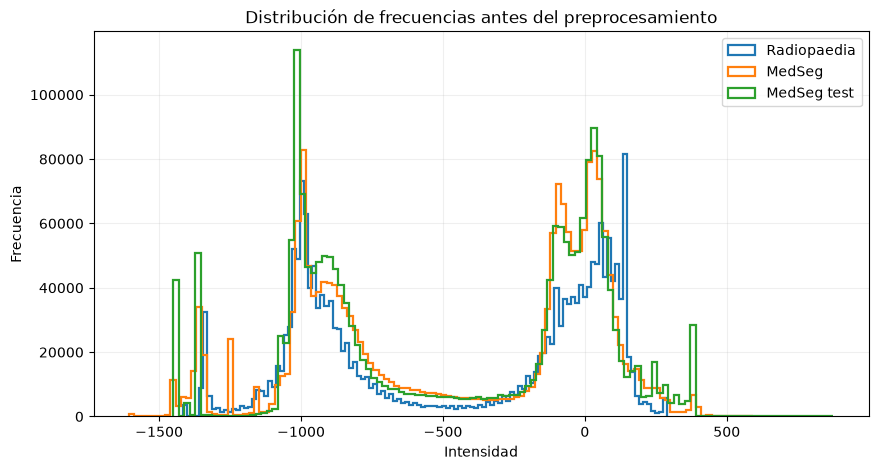

In [45]:
def systematic_pixel_sample(images, max_samples=2_000_000):
    ## Calcula todos los pixeles de las imagenes y toma una muestra de tamaño max_samples para graficar la distribución de intensidades
    flat = images.reshape(-1)
    sample_size = min(max_samples, flat.size)
    sample_indices = np.linspace(0, flat.size - 1, sample_size, dtype=np.int64)
    return flat[sample_indices]

plt.figure(figsize=(10, 5))
for label, images, color in [
    ('Radiopaedia', images_radiopedia, 'tab:blue'),
    ('MedSeg', images_medseg, 'tab:orange'),
    ('MedSeg test', test_images_medseg, 'tab:green'),
]:
    sample = systematic_pixel_sample(images)
    plt.hist(
        sample,
        bins=120,
        histtype='step', linewidth=1.6, label=label, color=color
    )
plt.title('Distribución de frecuencias antes del preprocesamiento')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### 5.6 Presencia de clases por imagen

Se cuenta en cuántos cortes aparece al menos un píxel de cada clase. Esta medida complementa el balance por píxel: una lesión puede ocupar pocos píxeles y, aun así, estar presente en muchas imágenes.

La función de class_presence_onehot, recibe los siguientes parametros:

- masks: Arreglo con las máscaras de segmentación codificadas en formato one-hot.
- source: identificador de la fuente del conjunto de máscaras.
- batch_size: Número de máscaras que se procesan simultáneamente.


Esta función se utiliza para contar cuantas veces una clase está presente en una imagen, considerando que para que esté presente debe existir al menos un pixel de esa clase por imagen. La función supone que las mascaras se encuentran en formato one_hot.

Se observa que el conjunto de radiopedia tiene una proporción mayor que contiene valores de la clase de vidrio esmerilado o consolidación, mientras que Radiopaedia, tiene concentraciones muy bajas de estas dos clases y es el conjunto con más datos, por lo que podría favorecer el aprendizaje del fondo y perjudicar la sensibilidad del modelo a detectar las lesiones pequeñas.

,fuente,clase,imágenes_con_clase,total_imágenes,porcentaje_imágenes
0,Radiopaedia,Vidrio esmerilado,297,829,35.83
1,Radiopaedia,Consolidación,233,829,28.11
2,Radiopaedia,Otras regiones pulmonares,713,829,86.01
3,Radiopaedia,Fondo,829,829,100.00
4,MedSeg,Vidrio esmerilado,96,100,96.00
5,MedSeg,Consolidación,78,100,78.00
6,MedSeg,Otras regiones pulmonares,100,100,100.00
7,MedSeg,Fondo,100,100,100.00


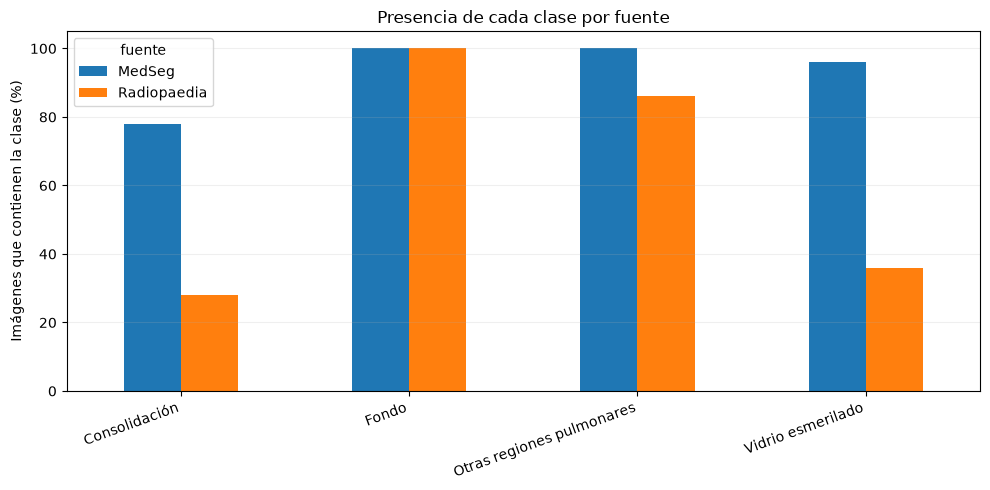

In [46]:
class_names = ['Vidrio esmerilado', 'Consolidación', 'Otras regiones pulmonares', 'Fondo']

def class_presence_onehot(masks, source, batch_size=16):
    presence = np.zeros(masks.shape[-1], dtype=np.int64)
    for start in range(0, len(masks), batch_size):
        block = masks[start:start + batch_size]
        presence += np.any(block != 0, axis=(1, 2)).sum(axis=0)
    return [
        {
            'fuente': source,
            'clase': class_names[class_index],
            'imágenes_con_clase': int(presence[class_index]),
            'total_imágenes': len(masks),
            'porcentaje_imágenes': 100 * presence[class_index] / len(masks),
        }
        for class_index in range(len(class_names))
    ]

eda_class_presence = pd.DataFrame(
    class_presence_onehot(masks_radiopedia, 'Radiopaedia')
    + class_presence_onehot(masks_medseg, 'MedSeg')
)
eda_class_presence['porcentaje_imágenes'] = eda_class_presence['porcentaje_imágenes'].round(2)
display(eda_class_presence)

presence_plot = eda_class_presence.pivot(
    index='clase', columns='fuente', values='porcentaje_imágenes'
)
presence_plot.plot(kind='bar', figsize=(10, 5), ylim=(0, 105))
plt.title('Presencia de cada clase por fuente')
plt.ylabel('Imágenes que contienen la clase (%)')
plt.xlabel('')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Función para ver imágenes
La función visualize tiene los siguientes parametros:

- image_batch: Grupo de imagenes.
- mask_batch: Grupo de máscaras correctas.
- pred_batch: Predicciones del grupo.
- num_samples: Número de muestras para mostrar.
- hot_encode: Variable booleana para escoger la forma de indexar.

Nos ayuda a dependiendo el numero de muestras que queremos visualizar, recorrer 
el número de num_samples y si tenemos la clase indexa hasta la clase si no solo 
agarra todos los pixeles de la imagen y los guarda para mostrarlos. Si recibe 
predicciones arma una imagen de tres canales, rojo para las predicciones, verde
para los correctos y amarrillo para los que coinciden ambos.

In [47]:
def visualize(image_batch, mask_batch=None, pred_batch=None, num_samples=8, hot_encode=True):
    num_classes = mask_batch.shape[-1] if mask_batch is not None else 0
    _, ax       = plt.subplots(num_classes + 1, num_samples, figsize=(num_samples * 2, (num_classes + 1) * 2))

    for i in range(num_samples):
        ax_image = ax[0, i] if num_classes > 0 else ax[i]
        if hot_encode: 
            ax_image.imshow(image_batch[i,:,:,0], cmap='Greys')
        else: 
            ax_image.imshow(image_batch[i,:,:])
        ax_image.set_xticks([]) 
        ax_image.set_yticks([])
        
        if mask_batch is not None:
            for j in range(num_classes):
                if pred_batch is None:
                    mask_to_show = mask_batch[i,:,:,j]
                else:
                    mask_to_show = np.zeros(shape=(*mask_batch.shape[1:-1], 3)) 
                    mask_to_show[..., 0] = pred_batch[i,:,:,j] > 0.5
                    mask_to_show[..., 1] = mask_batch[i,:,:,j]
                ax[j + 1, i].imshow(mask_to_show, vmin=0, vmax=1)
                ax[j + 1, i].set_xticks([]) 
                ax[j + 1, i].set_yticks([]) 

    plt.tight_layout()
    plt.show()

## 7. Función para compactar respuestas
La función onehot_to_mask tiene los siguientes parámetros:

- mask: Máscara con un canal por clase.
- palette: Equivalencia entre índice y etiqueta.

Su propósito es convertir una máscara one-hot de forma (alto, ancho, clases) en una sola etiqueta por píxel. Esta conversión es necesaria porque funciones como CrossEntropyLoss esperan que la respuesta correcta sea un índice entero de clase por píxel, no varios canales binarios.

np.argmax(mask, axis=-1) busca, en cada píxel, el canal con el valor más alto porque ese canal representa la clase asignada. Si dos canales tienen el mismo valor máximo, NumPy selecciona el primero. Luego se convierte palette en un arreglo para usar esos índices como posiciones y recuperar la etiqueta correspondiente. Finalmente se utiliza uint8 porque solo se almacenan identificadores pequeños de clase; esto conserva la información y consume menos memoria que un tipo flotante.

In [48]:
def onehot_to_mask(mask, palette):
    """
    Converts a mask (H, W, K) to (H, W, C)
    """
    x = np.argmax(mask, axis=-1)
    colour_codes = np.array(palette)
    x = np.uint8(colour_codes[x.astype(np.uint8)])
    return x

## 8. Función para procesar imágenes
La función preprocess_images tiene los siguientes parámetros:

- images_arr: Arreglo que contiene las imágenes que se procesarán.
- mean_std: Tupla opcional con la media y la desviación estándar que se usarán para estandarizar las imágenes.

El propósito de preprocess_images es colocar todas las tomografías en una escala numérica consistente y estable para el modelo. Primero limita las intensidades al intervalo [-1500, 500]. Este clipping reduce la influencia de valores extremos, ruido o materiales muy densos sin eliminar píxeles completos, y conserva el rango de unidades Hounsfield que contiene la mayor parte de la información pulmonar relevante.

Después calcula los percentiles 5 y 95 y usa solamente los valores intermedios para obtener la media y la desviación estándar. Se hace así para que las estadísticas no queden dominadas por el aire, el fondo u otros valores atípicos. La operación (images_arr - mean) / std centra los datos alrededor de cero y ajusta su escala, lo cual suele hacer más estable la optimización de la red.

La media y la desviación solo se calculan con el conjunto de referencia, normalmente entrenamiento. Los conjuntos de validación y prueba reciben la misma tupla mediante mean_std; reutilizarla evita fuga de información y garantiza que una misma intensidad tenga la misma representación en todos los conjuntos. La función devuelve también estas estadísticas para poder aplicarlas posteriormente de forma consistente.

In [49]:
def preprocess_images(images_arr, mean_std=None):
    # Clipping
    images_arr[images_arr > 500]    = 500
    images_arr[images_arr < -1500]  = -1500
    # Robust scaling
    min_perc, max_perc  = np.percentile(images_arr, 5), np.percentile(images_arr, 95)
    images_arr_valid    = images_arr[(images_arr > min_perc) & (images_arr < max_perc)]
    # Standarization
    mean, std           = (images_arr_valid.mean(), images_arr_valid.std()) if mean_std is None else mean_std
    images_arr          = (images_arr - mean) / std
    print(f'mean {mean}, std {std}')
    return images_arr, (mean, std)

## 9. Función para comparar distribuciones
La función plot_hists tiene los siguientes parámetros:

- images1: Primer grupo de imágenes que se representará en el histograma.
- images2: Segundo grupo de imágenes que se comparará; es opcional.

El propósito de plot_hists es comprobar visualmente si dos conjuntos de imágenes tienen distribuciones de intensidad parecidas, especialmente después del preprocesamiento. Una diferencia grande puede revelar escalas incompatibles, valores atípicos o un cambio de dominio entre entrenamiento y prueba que podría perjudicar las predicciones.

ravel() aplana todas las imágenes porque el histograma necesita una secuencia de intensidades y aquí no importa la posición espacial de cada píxel. Se utilizan 100 intervalos para mostrar suficiente detalle sin producir una gráfica excesivamente ruidosa. density=True normaliza cada histograma: así se comparan las formas de las distribuciones aunque los conjuntos tengan cantidades distintas de píxeles. Cuando existen dos conjuntos, la transparencia permite observar sus zonas de superposición.

In [50]:
def plot_hists(images1, images2=None):
    plt.hist(images1.ravel(), bins=100, density=True, color='b', alpha=1 if images2 is None else 0.5)
    if images2 is not None:
        plt.hist(images2.ravel(), bins=100, density=True, alpha=0.5, color='orange')
    plt.show()

## 10. Función para calcular la exactitud por píxel
La función pixel_accuracy tiene los siguientes parámetros:

- output: Salida del modelo con los valores calculados para cada clase.
- mask: Máscara real que contiene la clase correcta de cada píxel.

El propósito de pixel_accuracy es medir qué proporción de píxeles fue clasificada correctamente. softmax transforma los logits del modelo en valores comparables entre clases y argmax selecciona la clase con mayor valor en cada píxel. Luego torch.eq construye un mapa de aciertos y la suma se divide entre el número total de píxeles para obtener un valor entre 0 y 1.

El cálculo se encierra en torch.no_grad() porque la métrica solo sirve para observar el desempeño y no participa en la actualización de los pesos; evitar los gradientes reduce memoria y trabajo innecesario. Esta métrica es fácil de interpretar, pero en segmentación puede ser engañosa si domina la clase de fondo: un modelo podría obtener una exactitud alta sin segmentar bien las lesiones. Por eso se utiliza junto con mIoU.

In [51]:

def pixel_accuracy(output, mask):
    with torch.no_grad():
        output = torch.argmax(F.softmax(output, dim=1), dim=1)
        correct = torch.eq(output, mask).int()
        accuracy = float(correct.sum()) / float(correct.numel())
    return accuracy


## 11. Función para calcular la intersección sobre unión media
La función mIoU tiene los siguientes parámetros:

- pred_mask: Salida del modelo con los valores predichos para cada clase.
- mask: Máscara real con la clase correcta de cada píxel.
- smooth: Valor pequeño que evita divisiones entre cero.
- n_classes: Número de clases que se evaluarán; por defecto son cuatro.

El propósito de mIoU es medir la calidad de la superposición entre la región predicha y la real para cada clase. Es una métrica especialmente útil en segmentación porque penaliza tanto los píxeles que se marcaron de más como los que faltaron, y resulta más informativa que la exactitud cuando existe mucho fondo.

Primero se aplica softmax y después argmax para convertir los valores de salida en un único índice de clase por píxel. contiguous().view(-1) aplana predicción y respuesta real para comparar todos sus píxeles sin conservar las dimensiones espaciales; contiguous() asegura que la memoria tenga el orden que view necesita.

Para cada clase se crean mapas booleanos y se calcula intersección / unión: la intersección contiene los píxeles que ambas máscaras asignan a la clase y la unión contiene los que aparecen en al menos una. smooth evita una división entre cero por errores numéricos. Si una clase no existe en la máscara real se registra NaN, pues evaluarla en ese lote no aportaría información; np.nanmean la omite y promedia solamente las clases presentes. Todo se ejecuta sin gradientes porque mIoU es una métrica y no una función usada para entrenar.

In [52]:
def mIoU(pred_mask, mask, smooth=1e-10, n_classes=4):
    with torch.no_grad():
        pred_mask = F.softmax(pred_mask, dim=1)
        pred_mask = torch.argmax(pred_mask, dim=1)
        pred_mask = pred_mask.contiguous().view(-1)
        mask = mask.contiguous().view(-1)

        iou_per_class = []
        for clas in range(0, n_classes): #loop per pixel class
            true_class = pred_mask == clas
            true_label = mask == clas

            if true_label.long().sum().item() == 0: #no exist label in this loop
                iou_per_class.append(np.nan)
            else:
                intersect = torch.logical_and(true_class, true_label).sum().float().item()
                union = torch.logical_or(true_class, true_label).sum().float().item()

                iou = (intersect + smooth) / (union +smooth)
                iou_per_class.append(iou)
        return np.nanmean(iou_per_class)

## 12. Función para entrenar y validar el modelo
La función fit tiene los siguientes parámetros:

- epochs: Número de épocas durante las que se entrenará el modelo.
- model: Modelo que se entrenará.
- train_loader: Cargador de los datos de entrenamiento.
- val_loader: Cargador de los datos de validación.
- criterion: Función utilizada para calcular la pérdida.
- optimizer: Optimizador encargado de actualizar los pesos del modelo.
- scheduler: Programador que modifica la tasa de aprendizaje.
- patch: Parámetro opcional que actualmente no se utiliza dentro de la función.

get_lr recupera la tasa de aprendizaje actual del primer grupo de parámetros. Se guarda en cada paso porque OneCycleLR la cambia durante el entrenamiento y registrar su evolución ayuda a comprobar que el scheduler está funcionando como se esperaba.

El propósito de fit es concentrar el ciclo completo de aprendizaje y validación. Las listas iniciales conservan las métricas para analizarlas al terminar; min_loss, decrease y not_improve permiten vigilar si la pérdida de validación mejora, guardar puntos de control y detener un entrenamiento que ya no progresa. El modelo se mueve a device para aprovechar GPU si está disponible.

En cada época se reinician los acumuladores porque se desea obtener el promedio correspondiente solo a esa vuelta sobre los datos. model.train() activa el comportamiento de entrenamiento de capas como *dropout* y normalización por lotes. Para cada lote se mueven imágenes y máscaras al mismo dispositivo, se ejecuta el pase hacia adelante y criterion cuantifica el error que debe minimizarse. mIoU y exactitud se calculan en paralelo para interpretar la calidad de la segmentación desde perspectivas complementarias.

loss.backward() calcula cómo contribuye cada parámetro al error; optimizer.step() usa esos gradientes para actualizar los pesos y optimizer.zero_grad() los limpia porque PyTorch los acumula de manera predeterminada. Después se registra la tasa de aprendizaje y scheduler.step() la ajusta en cada lote, como requiere OneCycleLR.

Al terminar el entrenamiento de la época se usa model.eval() para evaluar con un comportamiento determinista y torch.no_grad() para no crear un grafo de cálculo. La validación se mantiene separada porque estima el desempeño en datos que no se usan para actualizar pesos. Las sumas se dividen entre el número de lotes para poder comparar épocas en una escala común. Si baja la pérdida de validación se considera una mejora y periódicamente se guarda el modelo; si deja de bajar durante varios intentos se detiene para evitar seguir gastando recursos y reducir el riesgo de sobreajuste. Finalmente, history reúne todas las curvas y permite graficarlas o compararlas posteriormente.

El parámetro patch no se utiliza en la implementación actual; parece haberse conservado para una posible variante de entrenamiento por parches.

In [53]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def fit(epochs, model, train_loader, val_loader, criterion, optimizer, scheduler, patch=False):
    train_losses,val_iou,val_acc,lrs = [],[],[],[]
    test_losses,train_iou,train_acc  = [],[],[]
    min_loss    = np.inf
    decrease    = 1
    not_improve = 0

    model.to(device)
    fit_time = time.time()
    for e in range(epochs):
        since        = time.time()
        running_loss = 0
        iou_score    = 0
        accuracy     = 0
        #training loop
        model.train()
        for _, data in enumerate(tqdm(train_loader)):
            #training phase
            image_tiles, mask_tiles = data
            image = image_tiles.to(device)
            mask  = mask_tiles.to(device)
            #forward
            output = model(image)
            
            loss = criterion(output, mask)
            #evaluation metrics
            iou_score += mIoU(output, mask)
            accuracy  += pixel_accuracy(output, mask)
            #backward
            loss.backward()
            optimizer.step() #update weight          
            optimizer.zero_grad() #reset gradient
            
            #step the learning rate
            lrs.append(get_lr(optimizer))
            scheduler.step()
            
            running_loss += loss.item()
            

        else:
            model.eval()
            test_loss     = 0
            test_accuracy = 0
            val_iou_score = 0
            #validation loop
            with torch.no_grad():
                for _, data in enumerate(tqdm(val_loader)):
                    image_tiles, mask_tiles = data

                    image = image_tiles.to(device); mask =mask_tiles.to(device);
                    output = model(image)
                    #evaluation metrics
                    val_iou_score +=  mIoU(output, mask)
                    test_accuracy += pixel_accuracy(output, mask)
                    #loss
                    loss = criterion(output, mask)                                  
                    test_loss += loss.item()
            
            #calculatio mean for each batch
            train_losses.append(running_loss/len(train_loader))
            test_losses.append(test_loss/len(val_loader))


            if min_loss > (test_loss/len(val_loader)):
                print('Loss Decreasing.. {:.3f} >> {:.3f} '.format(min_loss, (test_loss/len(val_loader))))
                min_loss = (test_loss/len(val_loader))
                decrease += 1
                if decrease % 5 == 0:
                    print('saving model...')
                    torch.save(model, 'Unet_efficientnet_b2_mIoU-{:.3f}.pt'.format(val_iou_score/len(val_loader)))
                    

            if (test_loss/len(val_loader)) > min_loss:
                not_improve += 1
                min_loss = (test_loss/len(val_loader))
                print(f'Loss Not Decrease for {not_improve} time')
                if not_improve == 7:
                    print('Loss not decrease for 7 times, Stop Training')
                    break
            
            #iou
            val_iou.append(val_iou_score/len(val_loader))
            train_iou.append(iou_score/len(train_loader))
            train_acc.append(accuracy/len(train_loader))
            val_acc.append(test_accuracy/ len(val_loader))
            print("Epoch:{}/{}..".format(e+1, epochs),
                  "Train Loss: {:.3f}..".format(running_loss/len(train_loader)),
                  "Val Loss: {:.3f}..".format(test_loss/len(val_loader)),
                  "Train mIoU:{:.3f}..".format(iou_score/len(train_loader)),
                  "Val mIoU: {:.3f}..".format(val_iou_score/len(val_loader)),
                  "Train Acc:{:.3f}..".format(accuracy/len(train_loader)),
                  "Val Acc:{:.3f}..".format(test_accuracy/len(val_loader)),
                  "Time: {:.2f}m".format((time.time()-since)/60))
        
    history = {'train_loss' : train_losses, 'val_loss': test_losses,
               'train_miou' :train_iou, 'val_miou':val_iou,
               'train_acc' :train_acc, 'val_acc':val_acc,
               'lrs': lrs}
    print('Total time: {:.2f} m' .format((time.time()- fit_time)/60))
    return history

## 13. Funciones para visualizar las métricas de entrenamiento
Las funciones plot_loss, plot_score y plot_acc tienen el siguiente parámetro:

- history: Diccionario con las pérdidas, los valores de mIoU y las exactitudes de entrenamiento y validación de cada época.

plot_loss grafica la pérdida para verificar si el proceso de optimización reduce el error. plot_score muestra mIoU porque interesa saber si las regiones predichas realmente se superponen con las reales. plot_acc muestra la exactitud por píxel como una referencia adicional, aunque debe interpretarse con cuidado por el posible desbalance entre fondo y lesiones.

En las tres gráficas se comparan entrenamiento y validación por época. Esta comparación ayuda a detectar subajuste, cuando ambas curvas presentan resultados pobres, y sobreajuste, cuando entrenamiento sigue mejorando pero validación empeora. Los marcadores facilitan distinguir cada época, mientras que el título, las etiquetas, la leyenda y la cuadrícula hacen que la evolución y las diferencias sean más fáciles de leer.

In [54]:
def plot_loss(history):
    plt.plot(history['val_loss'], label='val', marker='o')
    plt.plot( history['train_loss'], label='train', marker='o')
    plt.title('Loss per epoch'); plt.ylabel('loss');
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()
    
def plot_score(history):
    plt.plot(history['train_miou'], label='train_mIoU', marker='*')
    plt.plot(history['val_miou'], label='val_mIoU',  marker='*')
    plt.title('Score per epoch'); plt.ylabel('mean IoU')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()
    
def plot_acc(history):
    plt.plot(history['train_acc'], label='train_accuracy', marker='*')
    plt.plot(history['val_acc'], label='val_accuracy',  marker='*')
    plt.title('Accuracy per epoch'); plt.ylabel('Accuracy')
    plt.xlabel('epoch')
    plt.legend(), plt.grid()
    plt.show()

## 14. Función para predecir una máscara y calcular su mIoU
La función predict_image_mask_miou tiene los siguientes parámetros:

- model: Modelo que realizará la predicción.
- image: Imagen o grupo de imágenes que se enviará al modelo.
- mask: Máscara real utilizada para evaluar la predicción.
- mean: Media definida para la normalización; actualmente no se utiliza dentro de la función.
- std: Desviación estándar definida para la normalización; actualmente no se utiliza dentro de la función.

El propósito de predict_image_mask_miou es generar una máscara discreta y, como también se dispone de la respuesta real, evaluar inmediatamente su calidad con mIoU. Se usa model.eval() para desactivar el comportamiento propio del entrenamiento y obtener predicciones consistentes. El modelo, la imagen y la máscara se mueven al mismo device porque PyTorch no puede operar con tensores repartidos entre CPU y GPU.

torch.no_grad() evita calcular gradientes porque aquí no se actualizarán pesos, lo cual reduce el consumo de memoria y acelera la inferencia. model(image) produce un canal de *logits* por clase; mIoU compara esa salida con la máscara real y argmax(dim=1) elige una sola clase para cada píxel. La máscara elegida se mueve a CPU para poder visualizarla o convertirla a NumPy, y squeeze(0) elimina la dimensión del lote cuando solo se predice una muestra.

La salida completa también se devuelve y se reorganiza de (lote, clases, alto, ancho) a (lote, alto, ancho, clases) mediante permute; este formato es más conveniente para las funciones de visualización del notebook. Los parámetros mean y std no se utilizan aquí porque la función supone que las imágenes recibidas ya fueron normalizadas por el Dataset.

In [55]:
def predict_image_mask_miou(model, image, mask, mean=[0.485], std=[0.229]):
    model.eval()
    model.to(device)
    image = image.to(device)
    mask  = mask.to(device)

    with torch.no_grad():
        output = model(image)
        score  = mIoU(output, mask)
        masked = torch.argmax(output, dim=1)
        masked = masked.cpu().squeeze(0)
    return masked, score, output.permute(0, 2, 3,1)

## 15. Función para realizar predicciones con imágenes de prueba
La función test_predict tiene los siguientes parámetros:

- model: Modelo que realizará la predicción.
- image: Imagen de prueba que se transformará y enviará al modelo.
- mean: Media utilizada para normalizar la imagen.
- std: Desviación estándar utilizada para normalizar la imagen.

El propósito de test_predict es realizar inferencia sobre una imagen de prueba que todavía no ha pasado por el objeto Dataset. Por eso crea una transformación que convierte el arreglo en tensor y lo normaliza con la media y desviación estándar recibidas. Usar las mismas estadísticas del entrenamiento es indispensable para que el modelo reciba valores en la escala que aprendió.

Se activa model.eval() para que las capas se comporten en modo de inferencia, y tanto el modelo como la imagen se mueven al mismo dispositivo. Para una imagen bidimensional, ToTensor() produce la forma (canal, alto, ancho); torch.unsqueeze(image, 1) agrega la dimensión que falta y forma (lote, canal, alto, ancho), que es el formato esperado por U-Net.

La predicción se ejecuta dentro de torch.no_grad() porque no se entrenará el modelo. Softmax(dim=1) convierte los *logits* de los cuatro canales en probabilidades relativas por clase para cada píxel; esto permite aplicar después un umbral o comparar clases. Finalmente, permute(0, 2, 3, 1) mueve los canales al final y devuelve (lote, alto, ancho, clases), formato que utiliza visualize y que resulta cómodo para convertir a NumPy.

In [56]:
def test_predict(model, image, mean=[0.485], std=[0.229]):
    t     = T.Compose([T.ToTensor(), T.Normalize(mean, std)])
    image = t(image)
    model.eval()
    
    model.to(device)
    image = image.to(device)
    
    with torch.no_grad():
        output = model(torch.unsqueeze(image,1))
        output = nn.Softmax(dim=1)(output)
    return output.permute(0, 2, 3,1)

La función predict_image_mask_pixel, recibe los siguientes parametros:
- model: modelo entrenado que se desea probar
- image: lote de imagenes
- mask: respuesta correcta de cada pixel:
- mean y std: no son utilizados dentro de esta función.

Primero se establace al modelo en el modo de evaluación, después se carga en el cpu o gpu dependiendo de la disponibilidad, se realiza esto mismo con la imagen y la mascara.

Posteriormente con .no_grad() se le indica al modelo que no se requiere calcular gradientes nuevamente, sino solo evaluar. Después se guarda la salida del modelo con base en la imagen y se elige una de las 4 clases con la puntuación más grande.

Finalmente se retorna la mascara predicha y también la precisión de los pixeles.

Se utiliza esta función para predecir la calidad en general, sin embargo la métrica de accuracy puede ser engañosa, porque puede reportar que predice correctamente únicamente el fondo y no lo que realmente nos interesa, por eso se decide utilizar otra métrica como mIoU.

In [57]:
def predict_image_mask_pixel(model, image, mask, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    model.eval()
    model.to(device); image=image.to(device)
    mask = mask.to(device)
    with torch.no_grad():
        output = model(image)
        acc    = pixel_accuracy(output, mask)
        masked = torch.argmax(output, dim=1)
        masked = masked.cpu().squeeze(0)
        
    return masked, acc

La función mask_to_onehot tiene los siguientes parametros:

- mask: mascara con pixeles que tienen los indices de cada clase
- palette: valores que representan las clases

La función recorre para cada color en la paleta de colores para encontrar aquellos que sean iguales con cada combinación, reduce las dimensiones para que quede una matriz de 2x2. Finalmente se juntan los mapas de las cuatro clases.

Esta función los permite visualizar cada clase por separado.

In [58]:
def mask_to_onehot(mask, palette):
    """
    Converts a segmentation mask (H, W, C) to (H, W, K) where the last dim is a one
    hot encoding vector, C is usually 1 or 3, and K is the number of class.
    """
    semantic_map = []
    for colour in palette:
        equality  = np.equal(mask, colour)
        class_map = np.all(equality, axis=-1)
        semantic_map.append(class_map)
    semantic_map = np.stack(semantic_map, axis=-1).astype(np.float32)
    return torch.from_numpy(semantic_map)

La función miou_score, recibe los parametros:

- model: modelo entrenado
- test_set: el conjunto de prueba

Se inicializa una lista vacia y por cada número de lote (es ignorado este valor) y data, se recuperan los valores de la imagen y mascara de test_set. Se utiliza la función de predict_image_mask_miou() con el modelo y los parametros recuperados previamente y se guarda el resultado del score, el cual para cada iteración se guarda en una lista que al final se retorna.

La métrica de intersection over union compara cuanto se superpone la predicción y la mascara real, resulta más informativo que accuracy porque la mayoría de estas imagenes contienen el fondo. Esta función devuelve un valor por lote, más no por imagen.



In [59]:
def miou_score(model, test_set):
    score_iou = []
    for _, data in enumerate(tqdm(test_set)):
        img, mask = data
        _, score,_ = predict_image_mask_miou(model, img, mask)
        score_iou.append(score)
    return score_iou

Para ser instanciada un objeto de la clase Dataset se requieren los siguientes parametros:

- images: las imagenes CT
- masks: mascaras con los indices de las clases
- augmentations: transformaciones de Albumentations

Se asignan estos valores a la instancia, con los valores para la media y desviación estandar definidos como 0.485 y 0.229 respectivamente.

La función getitem recibe un indice númerico para seleccionar una muestra de imagen y mascara, se le aplica un aumento a la mascara e imagen, es importante que se le aplique a ambos porque si la imagen cambia pero la mascara no, la etiqueta no correspondería con la anatomia.

La función de len retorna la longitud de las imagenes.

La función de tiles, no se utiliza en el entrenamiento actual.

In [60]:
class Dataset:   
    def __init__(self, images, masks,augmentations=None):
        self.images = images
        self.masks = masks
        self.augmentations = augmentations
        self.mean = [0.485]
        self.std = [0.229]
    
    def __getitem__(self, i):
        image = self.images[i]
        mask = self.masks[i]
        
        if self.augmentations is not None:
            sample = self.augmentations(image=image, mask=mask)
            
            image, mask = Image.fromarray(np.squeeze(sample['image'], axis=2)), sample['mask']
        
        if self.augmentations is None:
            image = Image.fromarray(image)
        
        t = T.Compose([T.ToTensor(), T.Normalize(self.mean, self.std)])
        image = t(image)
        mask = torch.from_numpy(mask).long()
    
        return image, mask
    
    def __len__(self):
        return len(self.images)
    
    def tiles(self, image, mask):
        img_patches = image.unfold(1, 512, 512).unfold(2, 768, 768) 
        img_patches  = img_patches.contiguous().view(3,-1, 512, 768) 
        img_patches = img_patches.permute(1,0,2,3)
        
        mask_patches = mask.unfold(0, 512, 512).unfold(1, 768, 768)
        mask_patches = mask_patches.contiguous().view(-1, 512, 768)
        
        return img_patches, mask_patches

### Images from radiopedia are full CT volumes:
Class 0 is "ground glass"<br>
Class 1 is "consolidations"<br>
Class 2 is "lungs other" – it doesn't mean that it is healthy lungs (you don't need to predict this class)<br>
Class 3 is "background" – not lungs (you don't need to predict this class)<br>

En el siguiente bloque de codigo se utiliza la función visualize() la cual tiene como parametro por defecto num_samples=8, por eso solo vemos 8 fotografias de la 30 a la 37.

Este bloque resulta útil para inspeccionar visualmente el dataset y nos permite detectar imagenes vacias, valores atipicos, mascaras que no corresponder a la imagen, errores de etiquetado, etc.

Es decir, nos ayuda a descubrir problemas en los datos que de otras formas serían dificiles de ver.

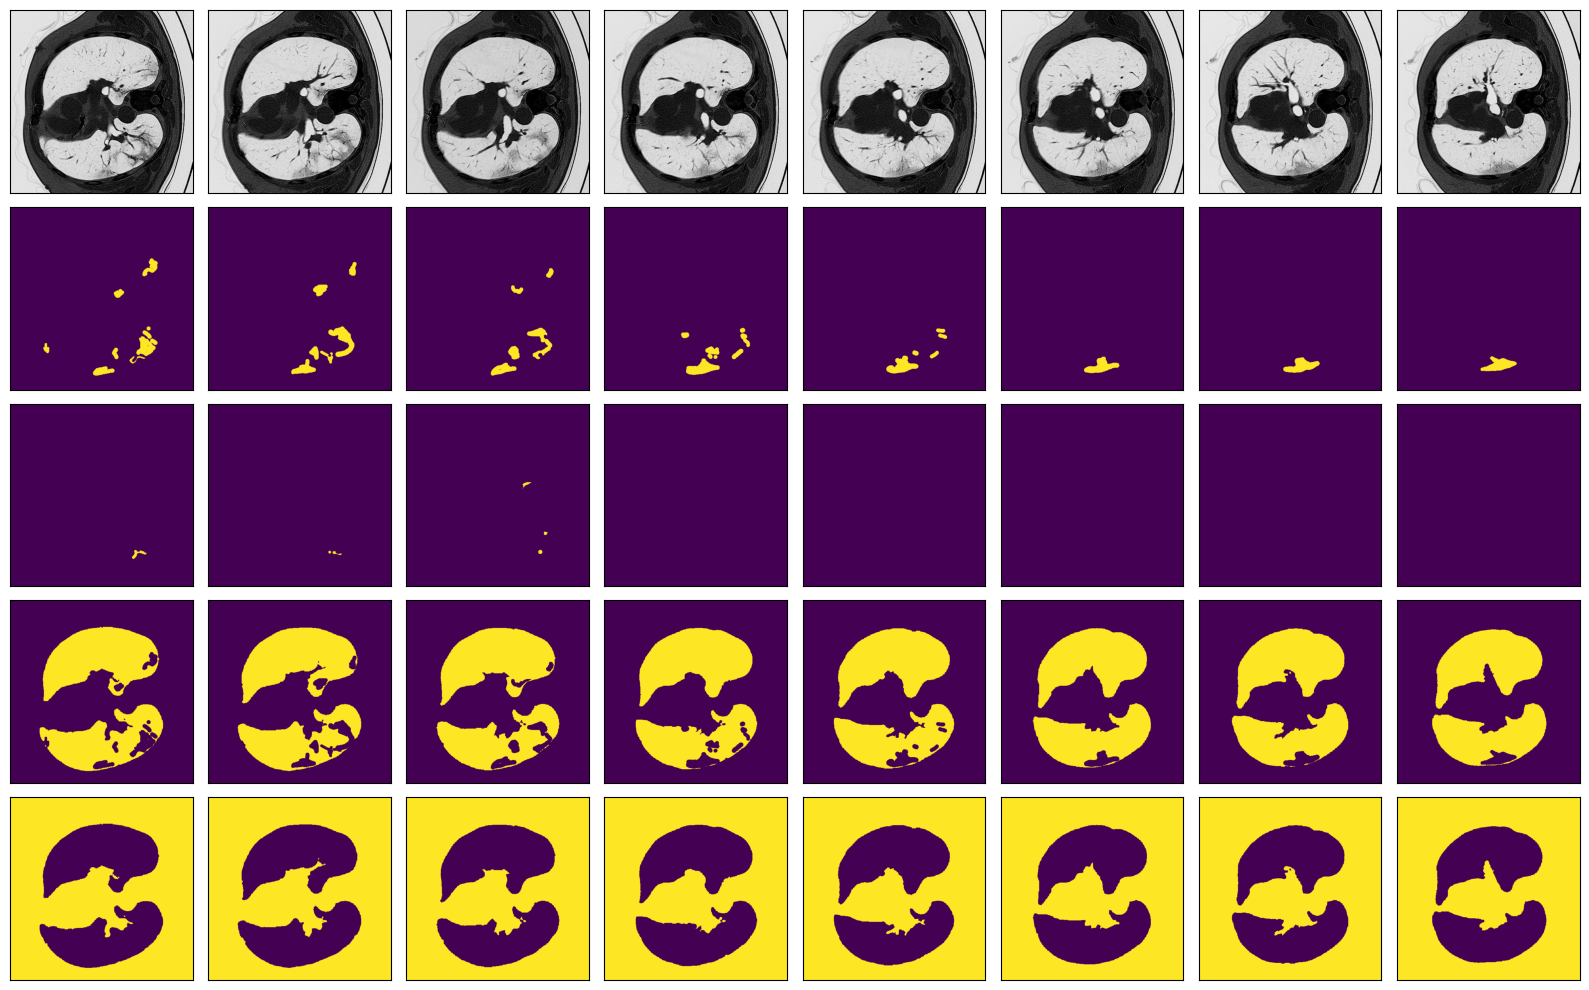

In [61]:
visualize(images_radiopedia[30:], masks_radiopedia[30:])

### Interpretación de las imágenes y máscaras de Radiopaedia

La primera fila muestra ocho cortes consecutivos de tomografía computarizada pertenecientes al conjunto Radiopaedia. Las cuatro filas siguientes representan las máscaras binarias *one-hot* asociadas a cada imagen. En estas máscaras, el color amarillo indica los píxeles que pertenecen a la clase correspondiente y el morado indica su ausencia.

De arriba hacia abajo, las máscaras representan:

1. **Opacidad de vidrio esmerilado:** se observan regiones pequeñas distribuidas dentro de los pulmones. Su extensión cambia gradualmente entre cortes consecutivos.
2. **Consolidación:** aparece en regiones considerablemente más pequeñas y llega a estar prácticamente ausente en algunos cortes.
3. **Otras regiones pulmonares:** comprende la mayor parte del área pulmonar que no fue etiquetada como vidrio esmerilado o consolidación.
4. **Fondo:** representa las zonas que no pertenecen a los pulmones, por lo que su máscara funciona aproximadamente como el complemento de la región pulmonar.

Las regiones etiquetadas como lesiones permanecen dentro de los pulmones y cambian de manera coherente entre cortes consecutivos, lo cual indica consistencia espacial en las anotaciones. También se observa un desbalance entre clases: el fondo y las regiones pulmonares ocupan muchos más píxeles que las lesiones, especialmente en comparación con la consolidación. Este desbalance puede hacer que la segmentación de las clases pequeñas sea más difícil y que métricas globales como la exactitud sean elevadas aun cuando algunas lesiones no se segmenten correctamente.

Estas imágenes corresponden a las máscaras reales del conjunto de datos y no a predicciones realizadas por el modelo.

El objetivo del siguiente bloque de codigo es convertir de one hot encoding con los valores de todos los pixeles y el que corresponde a la clase como 1, mientras que el resto son 0 a una forma donde directamente este el indice de la clase.

Por ello declaramos la paletta con las clases y para las mascaras de radiopedia y medseg ejecutamos la función onehot_to_mask() y con squeeze() eliminamos una dimensión adicional, cambiando la forma de representar la información de la clase. Esto es necesario porque CrossEntropyLoss necesita que la mascara tenga un indice entero por píxel.

In [62]:
palette = [[0], [1], [2],[3]]
masks_radiopedia_recover = onehot_to_mask(masks_radiopedia, palette).squeeze()  # shape = (H, W)

masks_medseg_recover = onehot_to_mask(masks_medseg, palette).squeeze()  # shape = (H, W)

print('Hot encoded mask size: ',masks_radiopedia.shape)
print('Paletted mask size:',masks_medseg_recover.shape)

visualize(masks_medseg_recover[30:],hot_encode=False)

KeyboardInterrupt: 

### Interpretación de las máscaras categóricas de MedSeg

La visualización muestra ocho máscaras de MedSeg después de convertir su representación *one-hot* en una única matriz de etiquetas categóricas. Por ello, cada píxel queda asignado exclusivamente a una de las cuatro clases.

De acuerdo con el orden definido en `palette`, los colores representan:

- **Morado oscuro:** clase 0, opacidad de vidrio esmerilado.
- **Azul o verde azulado:** clase 1, consolidación.
- **Verde:** clase 2, otras regiones pulmonares.
- **Amarillo:** clase 3, fondo.

Los colores son producidos por el mapa de color utilizado en la gráfica y únicamente permiten distinguir valores numéricos; no representan colores reales de los tejidos.

En las máscaras se observa que el fondo ocupa la región exterior de los pulmones, mientras que la clase correspondiente a otras regiones pulmonares cubre la mayor parte de su interior. Las clases asociadas con vidrio esmerilado y consolidación aparecen como regiones más pequeñas contenidas dentro del área pulmonar. Esto vuelve a mostrar un desbalance de clases, ya que las lesiones contienen muchos menos píxeles que el fondo y el resto del pulmón.

La conversión conserva la distribución espacial de las anotaciones y transforma una máscara con cuatro canales en una matriz bidimensional en la que existe una sola etiqueta de clase para cada píxel.

## Preprocess images:

En el siguiente bloque de codigo se ejecuta la limpieza y estandarización de las imagenes, donde se utiliza la función preprocess_images con los diferentes conjuntos de imagenes.

En esta se realiza el clipping con la función de contener los valores atipicos que pueden ser causados por aire fuera del cuerpo, ruido, metal, diferencias entre escaners, etc, en un rango definido para limitar aquellos valores muy grandes o muy pequeños.

Si no utilizaramos esta técnica los valores extremos podrían influir mucho en el modelo y dificultar su aprendizaje. Además de que de esta forma no eliminamos imagenes o pixeles, solo reemplazamos los valores extremos.

Finalmente se aplican estas transformaciones a los 3 conjuntos de imagenes para que todos se encuentren en la misma escala, porque si aplicaramos escalas diferentes para cada uno, un mismo valor en la imagen de CT podría representar cosas distintas para el modelo.

In [ ]:
images_radiopedia, mean_std = preprocess_images(images_radiopedia)
images_medseg, _ = preprocess_images(images_medseg, mean_std)
test_images_medseg, _ = preprocess_images(test_images_medseg, mean_std)

mean -451.6488342285156, std 458.56787109375
mean -451.6488342285156, std 458.56787109375
mean -451.6488342285156, std 458.56787109375


En este bloque se utiliza la función plot_hists() con el propósito de comparar la distribución de intensidades después de preprocesado de los datos.

Esto es importante porque nos permite verificar si los histogramas quedaron alineados de forma similar. Si estos fueran sustancialmente diferentes podría indicar problemas como diferentes escalas de intensidad, problemas en el preprocesado, valores atipicos, etc.

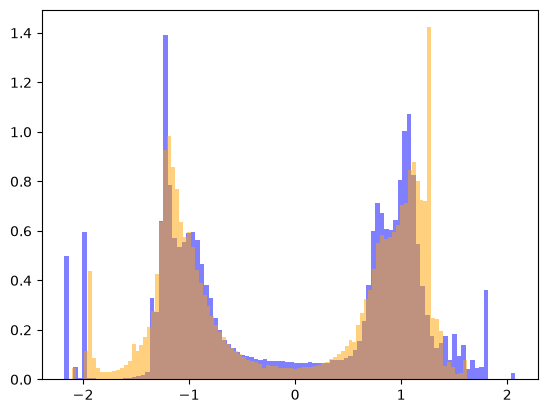

In [ ]:
plot_hists(test_images_medseg, images_radiopedia)

### Interpretación de la distribución de intensidades

El histograma compara las intensidades de los píxeles después del preprocesamiento. La distribución azul corresponde a las imágenes de prueba de **MedSeg** y la distribución naranja a las imágenes de **Radiopaedia**. El eje horizontal representa los valores de intensidad estandarizados, mientras que el eje vertical muestra su densidad de probabilidad, no el número absoluto de píxeles.

Ambos conjuntos presentan una distribución bimodal y un solapamiento considerable. Esto indica que la normalización aproxima sus escalas generales de intensidad y permite utilizarlos bajo un esquema de preprocesamiento común. La presencia de dos regiones principales en el histograma puede relacionarse con la separación entre diferentes grupos de intensidades presentes en los cortes, como las regiones de baja y alta densidad.

Sin embargo, las distribuciones no son idénticas. Radiopaedia presenta un pico positivo más pronunciado alrededor de 1.2–1.3, mientras que MedSeg concentra una parte mayor de sus valores cerca de 1.0 y muestra diferencias en los extremos de la distribución. Estas discrepancias indican que todavía existe un cambio de dominio entre los conjuntos, posiblemente debido a diferencias en los equipos, protocolos de adquisición o características de las imágenes originales.

Por lo tanto, aunque la estandarización reduce las diferencias entre ambos conjuntos, no las elimina completamente. Esto debe considerarse al evaluar el modelo, ya que fue entrenado con Radiopaedia y podría presentar una capacidad de generalización menor al aplicarse sobre MedSeg.

## Split/Train

Para realizar la separación de los datos, primero recuperamos nuevamente los valores de las mascaras con la función onehot_to_mask() y se definen los indices para el conjunto de validación (0 a 23) y entrenamiento (24 a 99).

Después se asignan las imagenes y mascaras con los valores de estos indices para estos dos conjuntos.

Sin embargo aquí identificamos una posible mejora, ya que los indices no se eligen aleatoriamente, así que si tuvieramos un dataset ordenado por paciente o severidad, las primeras 24 imagenes tendrían valores que podrían no representar del todo bien al conjunto completo. Por ello una separación estratificada sería más segura.

In [ ]:
masks_radiopedia_recover = onehot_to_mask(masks_radiopedia, palette).squeeze()  # shape = (H, W)
masks_medseg_recover     = onehot_to_mask(masks_medseg, palette).squeeze()  # shape = (H, W)

val_indexes, train_indexes = list(range(24)), list(range(24, 100))

train_images = np.concatenate((images_medseg[train_indexes], images_radiopedia))
train_masks  = np.concatenate((masks_medseg_recover[train_indexes], masks_radiopedia_recover))
val_images   = images_medseg[val_indexes]
val_masks    = masks_medseg_recover[val_indexes]

batch_size = len(val_masks)

del masks_medseg_recover
del masks_radiopedia_recover
del images_radiopedia
del masks_radiopedia
del images_medseg
del masks_medseg

### Balance por conjunto

Después de crear entrenamiento y validación, se compara tanto la proporción de píxeles como la proporción de imágenes que contienen cada clase. Una diferencia grande entre conjuntos indica que la validación no representa la misma dificultad ni prevalencia observada durante el entrenamiento.

La función categorical_mask_balance, recibe los siguientes parametros:

- masks: Arreglo que contiene las máscaras de segmentación en formato categórico. (n_imágenes, alto, ancho)
- split_name: Nombre del conjunto analizado.
- n_classes: Número total de clases posibles en las máscaras.
- batch_size: Número de máscaras procesadas simultáneamente.

Esta función calcula el balance de clases de un conjunto de máscaras categóricas. Es decir, para cada clase, cuenta el número total de píxeles etiquetados con esa clase y el número de imágenes en las que aparece al menos una vez.

Para la gráfica de Balance de pixeles por conjunto se describe de la cantidad total de pixeles cual es el porcentaje que pertenece a cada clase. Se observa que la gran cantidad de pixeles pertenecen a la clase de fondo, mientras que la clase de consolidación es la que menor cantidad de porcentaje de pixeles tiene en ambos conjuntos, seguido por vidrio esmerilado. Estas dos últimas clases son interesantes, por que en el conjunto de entrenamiento se observa que cuenta con una menor proporcion de estos, respecto a validación. 

La gráfica de presencia de clases por conjunto, indica en que porcentaje de cada imagen aparece al menos un pixel de cada clase. En esta se observa que para el conjunto de entrenamiento el vidrio esmerilado y consolidación aparecen unicamente en el 40.99% y 32.27% de las imagenes respectivamente, por lo que la mayoría de imagenes de este conjunto no presentan estas dos clases. En cambio en el conjunto de validación, este porcentaje para ambas clases aumenta a un 91.67% y un 79.17% para vidrio esmerilado y consolidación respectivamente.

Si conjuntamos la información de estas dos gráficas, significa que la segunda nos indica cuantas veces aparece cada clase en una imagen y la otra la proporción que representa la clase en una imagen, por lo que un alto porcentaje en la segunda gráfica y uno bajo en la segunda, como en el caso de vidrio esmerilado y consolidación del conjunto de validación, indica que aunque estas clases aparecen mucho, su proporción en la imagen es muy pequeña, mientras que un valor alto en ambas indica que aparecen mucho y predominan en la imagen, por último un valor pequeño en ambas, indica que no aparecen en muchas de las imagenes y que tampoco sobresalen en cada una de las imagenes.

,conjunto,clase,píxeles,porcentaje_píxeles,imágenes_con_clase,porcentaje_imágenes
0,Entrenamiento,Vidrio esmerilado,3147379,1.33,371,40.99
1,Entrenamiento,Consolidación,873040,0.37,292,32.27
2,Entrenamiento,Otras regiones pulmonares,35468965,14.95,789,87.18
3,Entrenamiento,Fondo,197750936,83.35,905,100.00
4,Validación,Vidrio esmerilado,268091,4.26,22,91.67
5,Validación,Consolidación,212422,3.38,19,79.17
6,Validación,Otras regiones pulmonares,1276271,20.29,24,100.00
7,Validación,Fondo,4534672,72.08,24,100.00


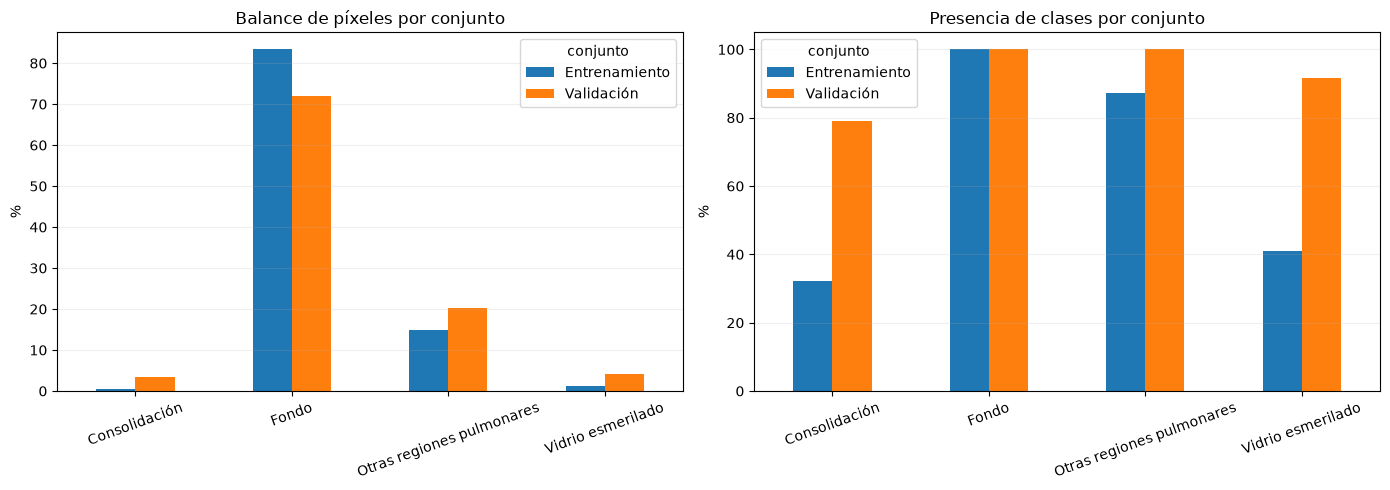

In [ ]:
def categorical_mask_balance(masks, split_name, n_classes=4, batch_size=16):
    pixel_counts = np.zeros(n_classes, dtype=np.int64)
    image_presence = np.zeros(n_classes, dtype=np.int64)

    for start in range(0, len(masks), batch_size):
        block = masks[start:start + batch_size]
        pixel_counts += np.bincount(block.reshape(-1), minlength=n_classes)[:n_classes]
        for class_index in range(n_classes):
            image_presence[class_index] += np.any(
                block == class_index, axis=(1, 2)
            ).sum()

    return [
        {
            'conjunto': split_name,
            'clase': class_names[class_index],
            'píxeles': int(pixel_counts[class_index]),
            'porcentaje_píxeles': 100 * pixel_counts[class_index] / pixel_counts.sum(),
            'imágenes_con_clase': int(image_presence[class_index]),
            'porcentaje_imágenes': 100 * image_presence[class_index] / len(masks),
        }
        for class_index in range(n_classes)
    ]

eda_split_balance = pd.DataFrame(
    categorical_mask_balance(train_masks, 'Entrenamiento')
    + categorical_mask_balance(val_masks, 'Validación')
)
eda_split_balance[['porcentaje_píxeles', 'porcentaje_imágenes']] = (
    eda_split_balance[['porcentaje_píxeles', 'porcentaje_imágenes']].round(2)
)
display(eda_split_balance)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, value, title in [
    (axes[0], 'porcentaje_píxeles', 'Balance de píxeles por conjunto'),
    (axes[1], 'porcentaje_imágenes', 'Presencia de clases por conjunto'),
]:
    eda_split_balance.pivot(index='clase', columns='conjunto', values=value).plot(
        kind='bar', ax=axis
    )
    axis.set_title(title)
    axis.set_ylabel('%')
    axis.set_xlabel('')
    axis.tick_params(axis='x', rotation=20)
    axis.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## Data generator and augmentations

En el siguiente bloque de codigo se aplican transformaciones y aumento de datos.

Para los aumentos de entrenamiento, primero se hace una rotación, en donde ayuda a que el 90% de las imagenes rote, lo que beneficia al modelo porque no dependerá de una orientación exacta y produce nuevas variantes sin recolectar nuevas imagenes, con el parametro de BORDER_REPLICATE rellena las esquinas copiando pixeles cercanos.

Después se hace un recorte aleatorio, que puede tener una altura entre 384 y 512 pixeles, para simular diferentes niveles de acercamiento, cambia la posición aparente de las lesiones y mejora la capacidad del modelo de generalizar, sin embargo un recorte puede eliminar parte de la zona que nos interesa o producir muestras sin la clase de interes.

Como siguiente paso se realiza un giro horizontal, donde la mitad de las imagenes se pueden ver afectadas, esto se realiza para que los pulmones presenten una simetria, porque una muestra de interes puede aparecer de ambos lados.

Para los aumentos de validación únicamente se redimensionan, a 256x256, es decir tienen 4 veces menos información, lo que representa un menor uso de memoria y un entrenamiento más rapido con el posible coste de perder detalles o que las zonas de interés puedan ser más dificiles de segmentar.

In [ ]:
SOURCE_SIZE = 512
TARGET_SIZE = 256

train_augs = albumentations.Compose([
    albumentations.Rotate(limit=360, p=0.9, border_mode=cv2.BORDER_REPLICATE),
    albumentations.RandomSizedCrop((int(SOURCE_SIZE * 0.75), SOURCE_SIZE), 
                                   (TARGET_SIZE, TARGET_SIZE), 
                                   interpolation=cv2.INTER_NEAREST),
    albumentations.HorizontalFlip(p=0.5),

])

val_augs = albumentations.Compose([
    albumentations.Resize(TARGET_SIZE, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)
])

En este bloque de codigo se crean los conjuntos de datos y los dataloaders.

Primero se instancian dos objetos de la clase Dataset para los conjuntos de train y validation, cada uno con sus respectivas mascaras, imagenes y los aumentos realizados en el bloque anterior.

Por último se instancian dos objetos de la clase DataLoader, donde hay una diferencia en el parametro de shuffle para cada uno de los dos conjuntos. Para train se manda como `true` porque se desea que el modelo no aprenda patrones relacionados con el orden del dataset y para val se manda como `false` porque nos interesa que sea fácil de reproducir la evaluación. 

In [ ]:
train_dataset    = Dataset(train_images, train_masks, train_augs)
val_dataset      = Dataset(val_images, val_masks, val_augs)       
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Este bloque permite inspeccionar visualmente la alineación entre las imágenes y sus máscaras en las primeras ocho muestras de un lote, así como observar la representación de las cuatro clases después de las transformaciones.

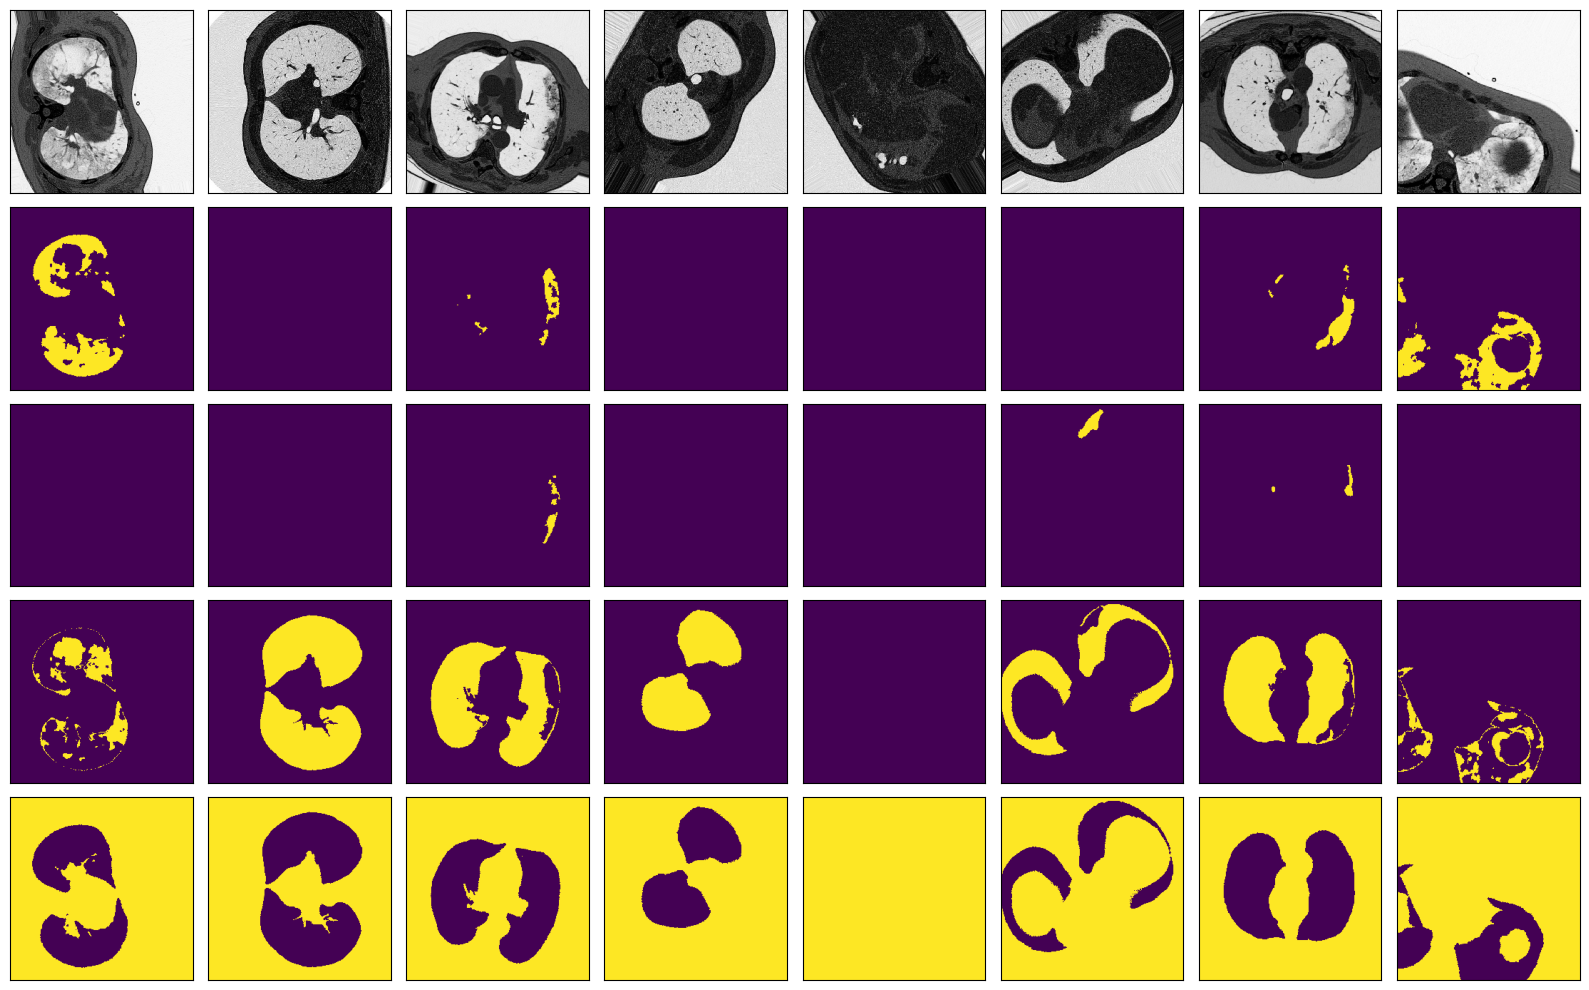

In [ ]:
i,train_data     = next(enumerate(train_dataloader))
mask_hot_encoded = mask_to_onehot(torch.unsqueeze(train_data[1],-1).numpy(),palette)
visualize(train_data[0].permute(0, 2, 3,1),mask_hot_encoded)

## Arquitectura del modelo: U-Net con encoder EfficientNet-B2

Se utilizó una **U-Net con encoder EfficientNet-B2 preentrenado en ImageNet**. U-Net está formada por tres componentes principales:

1. **Encoder:** reduce progresivamente la resolución y extrae características de la tomografía. Puede entenderse como **“¿qué estructuras aparecen en la imagen?”** En nuestro modelo, esta función la realiza EfficientNet-B2.

2. **Decoder:** recupera gradualmente la resolución para construir la máscara. Es entonces el **“¿en qué píxeles aparece cada estructura?”** Sus cinco etapas producen 256, 128, 64, 32 y 16 canales.

3. **Conexiones de salto (*skip connections*):** transfieren información del encoder al decoder. Funcionan como atajos que permiten recuperar bordes y detalles pequeños que podrían perderse al comprimir la imagen.

EfficientNet es una familia de redes convolucionales diseñada para obtener un buen equilibrio entre precisión y costo computacional. Sus variantes, desde B0 hasta B7, conservan una estructura similar, pero aumentan progresivamente la profundidad de la red, la cantidad de canales y la resolución de referencia. B0 es la variante más pequeña y rápida, mientras que las versiones superiores ofrecen mayor capacidad a cambio de más memoria y tiempo de procesamiento. Se eligió EfficientNet-B2 como encoder porque representa un punto intermedio: puede extraer características más complejas que B0 o B1 sin el elevado costo computacional de modelos como B4 o B7.

Se eligió EfficientNet-B2 porque ofrece un equilibrio entre capacidad y costo computacional: es más potente que las variantes B0 y B1, pero requiere menos memoria que modelos mayores como B4 o B7. Sus pesos preentrenados proporcionan detectores iniciales de bordes, formas y texturas. Durante el entrenamiento estos pesos también se actualizan para adaptarse a las tomografías.

La configuración utilizada es:

- `in_channels=1`: cada CT tiene un canal.
- `classes=4`: se predicen vidrio esmerilado, consolidación, otras regiones pulmonares y fondo.
- `encoder_depth=5`: se utilizan cinco niveles de resolución.
- `decoder_channels=[256, 128, 64, 32, 16]`: define los canales de las cinco etapas del decoder.
- `activation=None`: el modelo devuelve logits, ya que `CrossEntropyLoss` trabaja directamente con ellos.

Una imagen de entrada con forma `(1, 256, 256)` se comprime hasta una representación aproximada de `(352, 8, 8)`. Puede verse como pasar de una imagen detallada a un **resumen compacto de sus características**. El decoder expande después ese resumen y produce una salida `(4, 256, 256)`, es decir, cuatro valores por píxel. La clase con el valor más alto se toma como predicción.

### Diferencias respecto al notebook de inicio

La arquitectura no fue modificada: el notebook original y nuestra variante utilizan la misma U-Net con EfficientNet-B2. Esto permite comparar los experimentos manteniendo constante la estructura del modelo.

Las modificaciones se realizaron en el entrenamiento y la inferencia:

- pérdida ponderada combinada con Dice para atender mejor las lesiones pequeñas;
- aumentos de datos más conservadores;
- eliminación de una segunda normalización;
- selección del checkpoint mediante el mIoU de las lesiones;
- ajuste adaptativo de la tasa de aprendizaje;
- inferencia con reflexión horizontal y `argmax`.

Por lo tanto, **no propusimos una nueva arquitectura**, sino una estrategia de entrenamiento e inferencia más orientada a las clases de lesión.

In [ ]:
model = smp.Unet('efficientnet-b2',in_channels=1, encoder_weights='imagenet',classes=4, activation=None, encoder_depth=5, decoder_channels=[256, 128, 64, 32, 16])

## Entrenamiento

Aqui se configuran los hiperparametros del entrenamiento y se manda llamar la funcion fit().

max_lr es la tasa de aprendizaje maxima que va a usar el scheduler, epoch el numero de epocas y weight_decay la regularizacion L2 para que el modelo no se sobreajuste.

Como funcion de perdida se usa CrossEntropyLoss, que es la adecuada para este problema porque se tiene una clasificacion multiclase por pixel (cada pixel pertenece a una sola clase). El optimizador es AdamW y el scheduler es OneCycleLR, que va subiendo y despues bajando la tasa de aprendizaje a lo largo del entrenamiento en lugar de mantenerla fija.

Finalmente se llama a fit(), la cual entrena el modelo, calcula las metricas en cada epoca (loss, mIoU y accuracy tanto de entrenamiento como de validacion), guarda el modelo cuando mejora la perdida de validacion y detiene el entrenamiento si no mejora durante 7 epocas seguidas.

In [ ]:
max_lr       = 1e-2
epoch        = 10
weight_decay = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
sched     = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epoch,
                                            steps_per_epoch=len(train_dataloader))

history = fit(epoch, model, train_dataloader, val_dataloader, criterion, optimizer, sched)

100%|██████████| 1/1 [00:00<00:00, 10.07it/s]


Loss Decreasing.. inf >> 1.387 
Epoch:1/10.. Train Loss: 0.842.. Val Loss: 1.387.. Train mIoU:0.341.. Val mIoU: 0.352.. Train Acc:0.682.. Val Acc:0.835.. Time: 0.20m


100%|██████████| 1/1 [00:00<00:00, 10.72it/s]


Loss Not Decrease for 1 time
Epoch:2/10.. Train Loss: 0.107.. Val Loss: 168018.141.. Train mIoU:0.466.. Val mIoU: 0.051.. Train Acc:0.967.. Val Acc:0.203.. Time: 0.17m


100%|██████████| 1/1 [00:00<00:00, 10.91it/s]


...

Loss Decreasing.. 0.466 >> 0.208 
Epoch:8/10.. Train Loss: 0.044.. Val Loss: 0.208.. Train mIoU:0.707.. Val mIoU: 0.598.. Train Acc:0.984.. Val Acc:0.936.. Time: 0.18m


100%|██████████| 1/1 [00:00<00:00, 11.39it/s]


Loss Decreasing.. 0.208 >> 0.205 
Epoch:9/10.. Train Loss: 0.043.. Val Loss: 0.205.. Train mIoU:0.744.. Val mIoU: 0.607.. Train Acc:0.984.. Val Acc:0.939.. Time: 0.18m


100%|██████████| 1/1 [00:00<00:00, 11.17it/s]

Loss Decreasing.. 0.205 >> 0.202 
saving model...
Epoch:10/10.. Train Loss: 0.041.. Val Loss: 0.202.. Train mIoU:0.743.. Val mIoU: 0.605.. Train Acc:0.985.. Val Acc:0.940.. Time: 0.17m
Total time: 1.74 m


Se guarda el modelo entrenado en disco con torch.save, esto guarda tanto la arquitectura como los pesos, no solo el state_dict, por lo que despues se puede cargar directamente con torch.load sin necesidad de volver a definir la clase del modelo.

In [ ]:
torch.save(model, 'Unet-efficientnet.pt')

En este bloque se grafican los resultados del entrenamiento usando las funciones plot_loss, plot_score y plot_acc definidas anteriormente, a partir del history que regresa fit(). Estas graficas sirven para ver como evoluciona la perdida, el mIoU y el accuracy en cada epoca, tanto para entrenamiento como para validacion, y permiten detectar si el modelo se esta sobreajustando.

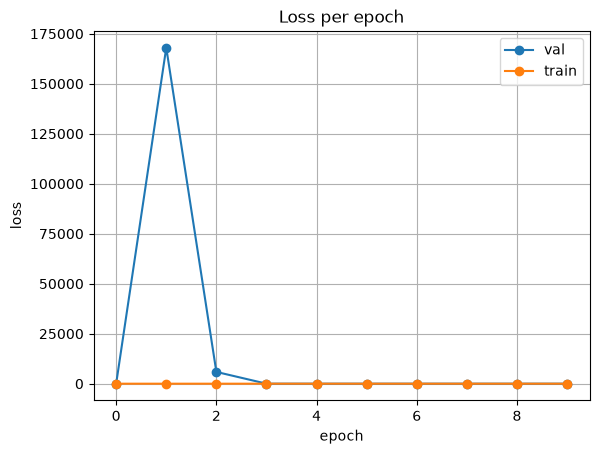

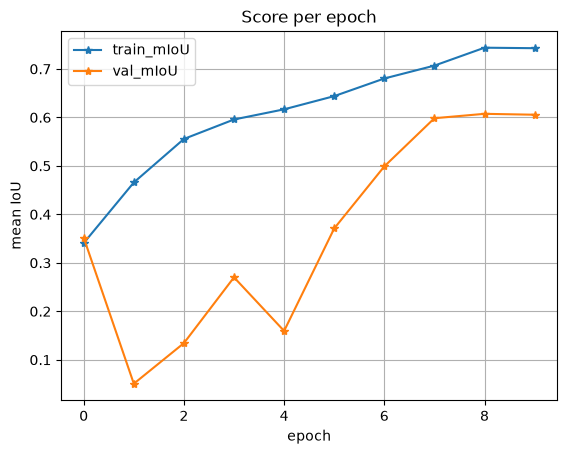

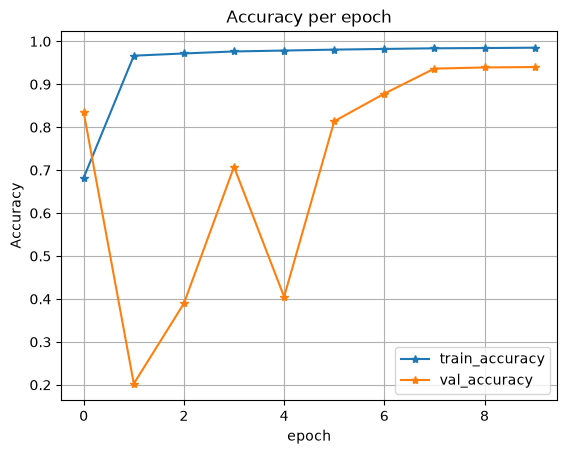

In [ ]:
plot_loss(history)
plot_score(history)
plot_acc(history)

## Evaluation

### Result

Se toma un lote del val_dataloader y se usa la funcion predict_image_mask_miou para obtener la mascara predicha, el mIoU de ese lote y la salida del modelo. Tambien se convierte la mascara real a one-hot con mask_to_onehot para poder compararla despues visualmente con la prediccion.

In [ ]:
image, mask             = next(iter(val_dataloader))
pred_mask, score,output = predict_image_mask_miou(model, image, mask)
semantic_map            = mask_to_onehot(torch.unsqueeze(mask,-1).numpy(),palette)

Se llama a visualize() pasando la imagen, la mascara real y la salida del modelo como pred_batch. Al mandar pred_batch la funcion pinta en rojo lo que predijo el modelo y en verde la mascara real, entonces donde coinciden ambos se ve en amarillo, lo que facilita ver que tan bien esta segmentando cada clase.

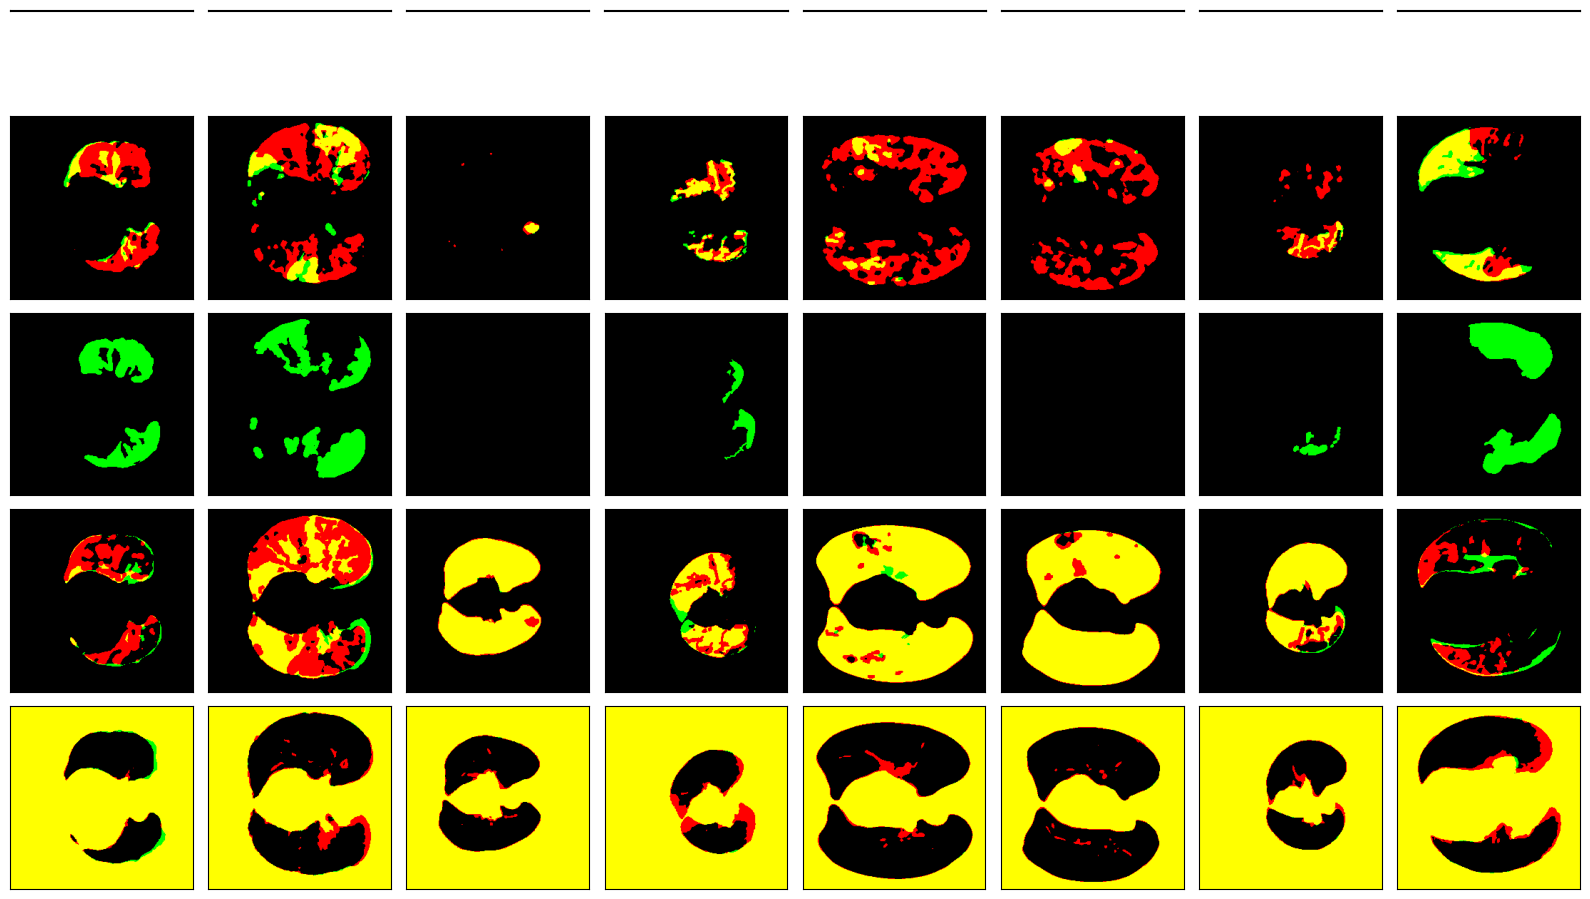

In [ ]:
visualize(image.cpu(), semantic_map, pred_batch=output.cpu())

Se usa la funcion miou_score para calcular el mIoU en todo el conjunto de validacion, recorriendolo lote por lote, y se obtiene una lista con un valor de mIoU por cada lote.

In [ ]:
mob_miou = miou_score(model, val_dataloader)
mob_miou

100%|██████████| 1/1 [00:00<00:00,  8.05it/s]


[np.float64(0.6054922386714199)]

Se eliminan train_images y train_masks porque ya no se van a volver a usar (el entrenamiento ya termino), esto libera memoria antes de trabajar con las imagenes de test.

In [ ]:
del train_images
del train_masks

## Test preds:

En este bloque se predice sobre las imagenes de test. Primero se les aplica val_augs para dejarlas del mismo tamaño (256x256) que espera el modelo. Despues se recorre cada imagen y se le aplica test_predict, guardando las probabilidades de cada clase en output. Se umbraliza con >0.5 para quedarnos con una mascara binaria por clase y al final se visualizan las imagenes junto con sus predicciones.

torch.Size([10, 256, 256, 1])
(256, 256, 1)
(10, 256, 256, 4)


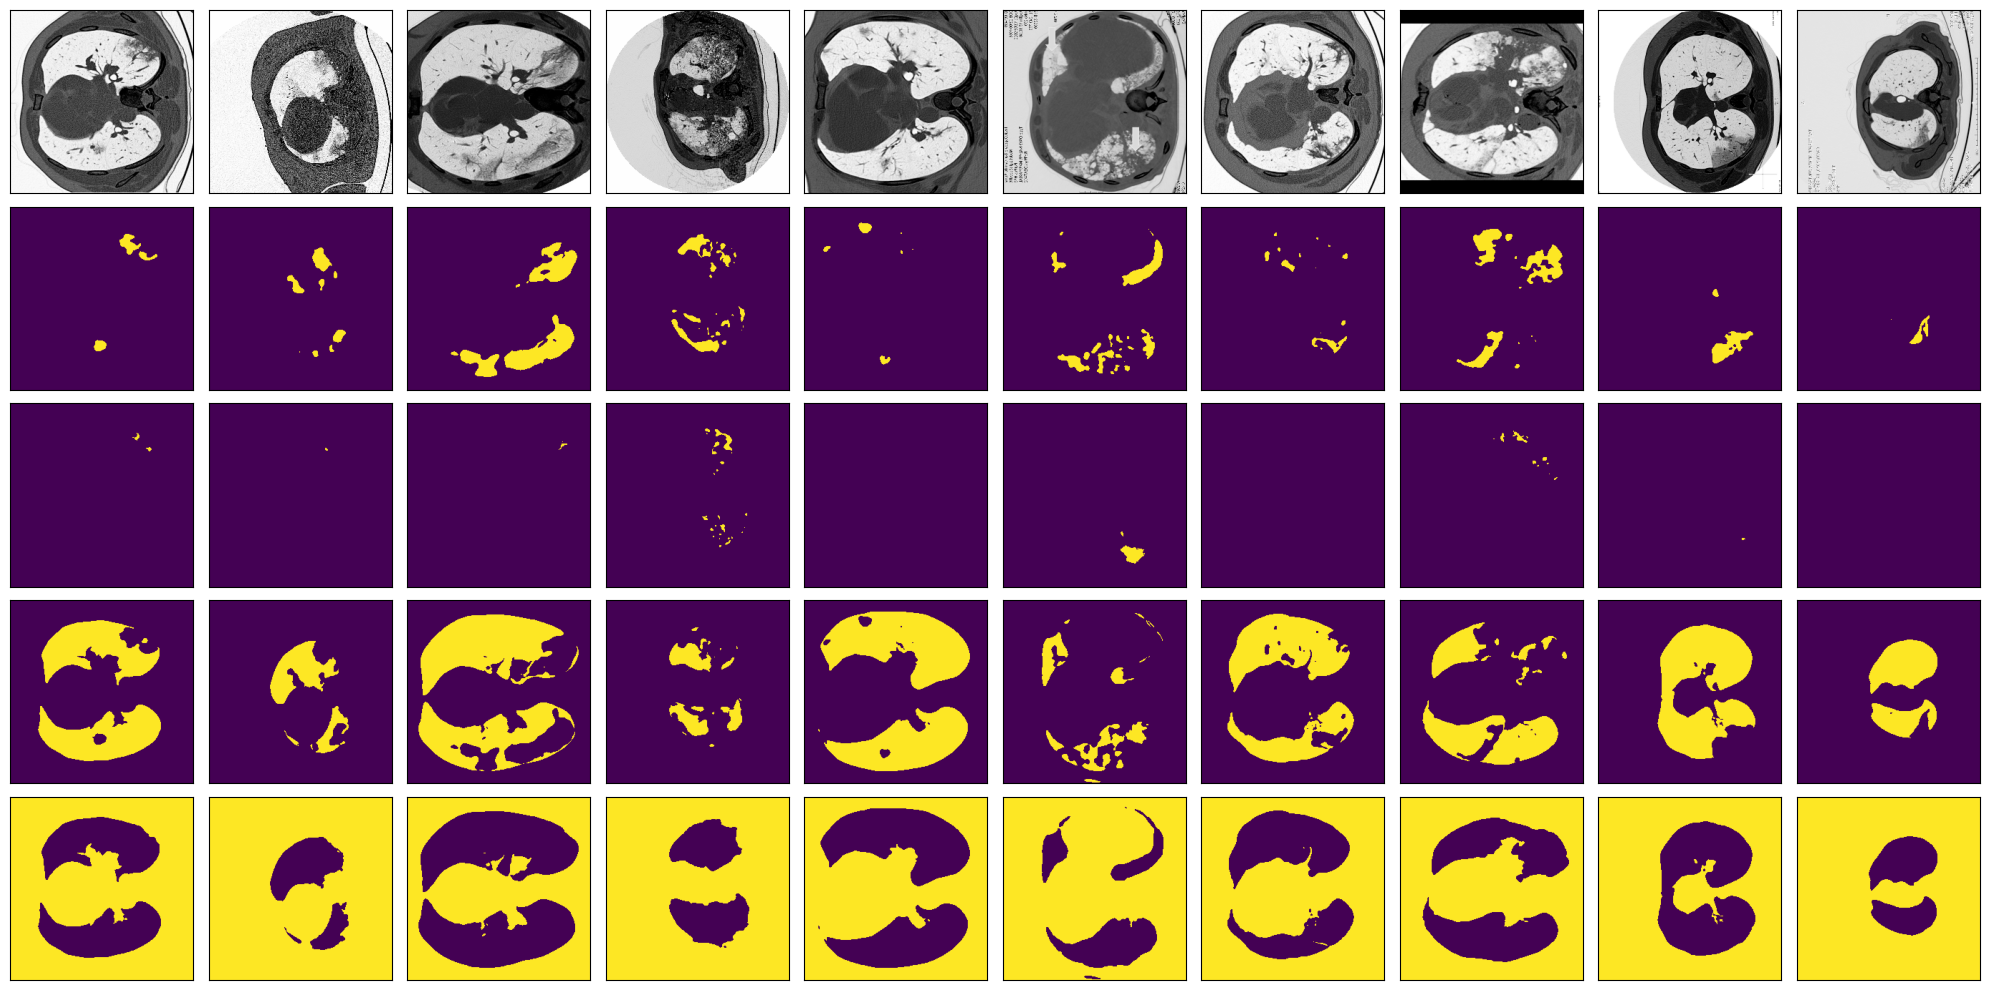

In [ ]:
image_batch = np.stack([val_augs(image=img)['image'] for img in test_images_medseg], axis=0)
print(torch.from_numpy(image_batch).shape)
print(image_batch[i].shape)
#output = test_predict(model, torch.from_numpy(image_batch).permute(0, 3, 1,2))
output = np.zeros((10,256,256,4))
for i in range(10):   
    output[i] = test_predict(model, image_batch[i]).cpu().numpy()
print(output.shape)
test_masks_prediction = output > 0.5
visualize(image_batch, test_masks_prediction, num_samples=len(test_images_medseg))

## Resize prediction to original size 

Como las predicciones se hicieron sobre imagenes redimensionadas a 256x256, aqui se regresan a su tamaño original (512x512) con scipy.ndimage.zoom, usando order=0 (vecino mas cercano) porque son mascaras discretas y no tendria sentido interpolar valores intermedios entre clases.

Ademas se descartan las ultimas dos clases con [..., :-2], ya que como se menciono antes, las clases de otros pulmones y fondo no son necesarias para la prediccion.

In [ ]:
test_masks_prediction_original_size = scipy.ndimage.zoom(test_masks_prediction[..., :-2], (1, 2, 2, 1), order=0)
test_masks_prediction_original_size.shape

(10, 512, 512, 2)

Por ultimo se genera el archivo para subir a la competencia. Se aplana el arreglo de predicciones y se arma un DataFrame con las columnas Id (el indice de cada valor) y Predicted (la clase predicha), y se guarda como sub.csv en el formato que pide Kaggle.

In [ ]:
pd.DataFrame(
             data=np.stack((np.arange(len(test_masks_prediction_original_size.ravel())), 
                            test_masks_prediction_original_size.ravel().astype(int)),
                            axis=-1), 
             columns=['Id', 'Predicted'])\
.set_index('Id').to_csv('sub.csv')

## Mejora propuesta: entrenamiento sensible a las lesiones e inferencia multiclase consistente

Esta sección es un experimento alternativo autocontenido. Para probarlo sin repetir el entrenamiento base, se pueden ejecutar las celdas originales hasta la creación de `train_dataset` y `val_dataset` y después saltar directamente a esta sección.

El análisis de las máscaras muestra un desbalance muy fuerte: en Radiopaedia, aproximadamente **84.25 %** de los píxeles son fondo, mientras que *ground glass* representa **1.02 %** y consolidación apenas **0.23 %**. Con `CrossEntropyLoss` sin pesos, el fondo domina el gradiente y el modelo puede obtener una exactitud alta aun cuando no delimite bien las lesiones. Además, las imágenes ya fueron estandarizadas por `preprocess_images`, pero la clase `Dataset` vuelve a aplicar `Normalize([0.485], [0.229])`; esa segunda normalización altera innecesariamente la escala aprendida.

La mejora añadida usa una pérdida híbrida: **Cross Entropy con pesos calculados a partir de la frecuencia de cada clase + Dice multiclase**. Cross Entropy conserva la clasificación correcta por píxel, los pesos elevan la importancia de las clases escasas y Dice optimiza directamente el solapamiento de las regiones. Se usa raíz cuadrada de la frecuencia inversa para compensar el desbalance sin producir pesos extremos. También se selecciona el mejor checkpoint por el mIoU medio de las dos lesiones (clases 0 y 1), que coincide mejor con el objetivo final que la pérdida global o la exactitud dominada por fondo.

La nueva clase de datos evita la doble normalización, mantiene `float32`, usa interpolación lineal para las tomografías y vecino más cercano únicamente para las máscaras. Las rotaciones se limitan a ±15 grados para conservar anatomía plausible. El lote se reduce respecto al lote de 24 imágenes usado antes, lo cual disminuye memoria y genera más actualizaciones por época. Para inferencia se promedian la imagen original y su reflejo horizontal (*test-time augmentation*) y después se aplica `argmax`: las cuatro clases son mutuamente excluyentes, por lo que umbralizar cada canal de `softmax` de forma independiente puede producir una codificación inconsistente.

**Qué se podría quitar después de validar la comparación:** la clase `Dataset` anterior, el `fit` anterior, el bloque que entrena solo con `CrossEntropyLoss` y el bloque de prueba que usa `output > 0.5`.

In [ ]:
# Componentes de la mejora. Este bloque no redefine ni modifica las funciones anteriores.
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

class ImprovedCTDataset(torch.utils.data.Dataset):
    """Dataset para imágenes ya estandarizadas por preprocess_images."""
    def __init__(self, images, masks=None, augmentations=None):
        self.images = images
        self.masks = masks
        self.augmentations = augmentations

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index]
        mask = None if self.masks is None else self.masks[index]

        if self.augmentations is not None:
            transformed = self.augmentations(image=image, mask=mask)
            image, mask = transformed['image'], transformed.get('mask')

        image = np.asarray(image, dtype=np.float32)
        if image.ndim == 2:
            image = image[..., None]
        image = torch.from_numpy(np.ascontiguousarray(image.transpose(2, 0, 1)))

        if mask is None:
            return image
        mask = torch.from_numpy(np.ascontiguousarray(mask, dtype=np.int64))
        return image, mask

def balanced_class_weights(masks, n_classes=4):
    counts = np.bincount(np.asarray(masks).reshape(-1), minlength=n_classes).astype(np.float64)
    weights = np.sqrt(counts.sum() / np.maximum(counts, 1.0))
    weights /= weights.mean()
    return torch.tensor(weights, dtype=torch.float32), counts.astype(np.int64)

class WeightedCrossEntropyDiceLoss(nn.Module):
    def __init__(self, class_weights, ce_weight=0.5, dice_weight=0.5, smooth=1.0):
        super().__init__()
        self.register_buffer('class_weights', class_weights)
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.class_weights)
        probabilities = torch.softmax(logits, dim=1)
        one_hot = F.one_hot(target, num_classes=logits.shape[1]).permute(0, 3, 1, 2).float()
        dimensions = (0, 2, 3)
        intersection = (probabilities * one_hot).sum(dimensions)
        denominator = probabilities.sum(dimensions) + one_hot.sum(dimensions)
        dice_per_class = (2.0 * intersection + self.smooth) / (denominator + self.smooth)
        dice_loss = 1.0 - dice_per_class.mean()
        return self.ce_weight * ce + self.dice_weight * dice_loss

def update_confusion_matrix(confusion, logits, target, n_classes=4):
    prediction = logits.argmax(dim=1)
    valid = (target >= 0) & (target < n_classes)
    indexes = n_classes * target[valid] + prediction[valid]
    return confusion + torch.bincount(indexes, minlength=n_classes ** 2).reshape(n_classes, n_classes)

def iou_from_confusion(confusion):
    confusion = confusion.float()
    intersection = confusion.diag()
    union = confusion.sum(0) + confusion.sum(1) - intersection
    return intersection / union.clamp_min(1.0)


In [ ]:
# Aumentos conservadores: interpolación continua para CT y discreta para etiquetas.
improved_train_augs = albumentations.Compose([
    albumentations.ShiftScaleRotate(
        shift_limit=0.05, scale_limit=0.10, rotate_limit=15,
        interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST,
        border_mode=cv2.BORDER_REFLECT_101, p=0.70
    ),
    albumentations.HorizontalFlip(p=0.50),
    albumentations.Resize(
        TARGET_SIZE, TARGET_SIZE,
        interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST
    )
])

improved_val_augs = albumentations.Compose([
    albumentations.Resize(
        TARGET_SIZE, TARGET_SIZE,
        interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST
    )
])

# train_dataset y val_dataset mantienen las referencias aunque las variables train_images/train_masks
# hayan sido eliminadas al final del experimento original. Se conserva exactamente el mismo split.
improved_train_dataset = ImprovedCTDataset(
    train_dataset.images, train_dataset.masks, improved_train_augs
)
improved_val_dataset = ImprovedCTDataset(
    val_dataset.images, val_dataset.masks, improved_val_augs
)

IMPROVED_BATCH_SIZE = 4
loader_generator = torch.Generator().manual_seed(SEED)
improved_train_loader = DataLoader(
    improved_train_dataset, batch_size=IMPROVED_BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=torch.cuda.is_available(), generator=loader_generator
)
improved_val_loader = DataLoader(
    improved_val_dataset, batch_size=IMPROVED_BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=torch.cuda.is_available()
)

class_weights, class_pixel_counts = balanced_class_weights(train_dataset.masks)
print('Píxeles por clase:', class_pixel_counts)
print('Pesos por clase:', class_weights.numpy().round(4))


In [ ]:
def fit_improved(model, train_loader, val_loader, criterion, optimizer, scheduler,
                 epochs=25, patience=6, checkpoint_path='Unet-efficientnet-improved.pt'):
    history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_lesion_miou': []}
    best_lesion_miou = -np.inf
    epochs_without_improvement = 0
    model.to(device)

    for epoch_index in range(epochs):
        model.train()
        train_loss = 0.0
        for images, masks in tqdm(train_loader, desc=f'Train {epoch_index + 1}/{epochs}'):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * images.size(0)

        model.eval()
        val_loss = 0.0
        confusion = torch.zeros((4, 4), dtype=torch.int64, device=device)
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc='Validation'):
                images = images.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)
                logits = model(images)
                val_loss += criterion(logits, masks).item() * images.size(0)
                confusion = update_confusion_matrix(confusion, logits, masks)

        train_loss /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        class_iou = iou_from_confusion(confusion).cpu().numpy()
        lesion_miou = float(class_iou[:2].mean())
        mean_iou = float(class_iou.mean())
        scheduler.step(lesion_miou)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(class_iou.tolist())
        history['val_lesion_miou'].append(lesion_miou)
        print(
            f'Epoch {epoch_index + 1:02d} | train_loss={train_loss:.4f} | '
            f'val_loss={val_loss:.4f} | mIoU={mean_iou:.4f} | '
            f'lesion_mIoU={lesion_miou:.4f} | IoU/clase={np.round(class_iou, 4)}'
        )

        if lesion_miou > best_lesion_miou + 1e-4:
            best_lesion_miou = lesion_miou
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint_path)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f'Early stopping. Mejor lesion_mIoU: {best_lesion_miou:.4f}')
                break

    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    return history

improved_model = smp.Unet(
    'efficientnet-b2', in_channels=1, encoder_weights='imagenet', classes=4,
    activation=None, encoder_depth=5, decoder_channels=[256, 128, 64, 32, 16]
)
improved_criterion = WeightedCrossEntropyDiceLoss(class_weights.to(device))
improved_optimizer = torch.optim.AdamW(improved_model.parameters(), lr=3e-4, weight_decay=1e-4)
improved_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    improved_optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-6
)

improved_history = fit_improved(
    improved_model, improved_train_loader, improved_val_loader, improved_criterion,
    improved_optimizer, improved_scheduler, epochs=25, patience=6
)


### Inferencia mejorada y archivo de entrega

El siguiente bloque usa el mejor checkpoint según `lesion_mIoU`. Promedia probabilidades de la imagen original y de su reflejo horizontal, deshace el reflejo y aplica `argmax` una sola vez. Después genera los dos canales binarios solicitados por la competencia y los redimensiona con vecino más cercano. El resultado se guarda en `sub_improved.csv` para no sobrescribir el archivo original `sub.csv`.

In [ ]:
def predict_with_horizontal_tta(model, images, batch_size=4):
    resized = np.stack([
        improved_val_augs(image=image)['image'] for image in images
    ])
    tensor = torch.from_numpy(
        np.ascontiguousarray(resized.transpose(0, 3, 1, 2), dtype=np.float32)
    )
    probabilities = []
    model.eval().to(device)

    with torch.no_grad():
        for start in range(0, len(tensor), batch_size):
            batch = tensor[start:start + batch_size].to(device)
            original_prob = torch.softmax(model(batch), dim=1)
            flipped_input = torch.flip(batch, dims=(-1,))
            flipped_prob = torch.flip(
                torch.softmax(model(flipped_input), dim=1), dims=(-1,)
            )
            probabilities.append(((original_prob + flipped_prob) / 2.0).cpu())

    probabilities = torch.cat(probabilities)
    predicted_class = probabilities.argmax(dim=1)
    lesion_channels = F.one_hot(predicted_class, num_classes=4)[..., :2]
    lesion_channels = lesion_channels.permute(0, 3, 1, 2).float()
    lesion_channels = F.interpolate(
        lesion_channels, size=(SOURCE_SIZE, SOURCE_SIZE), mode='nearest'
    )
    return lesion_channels.permute(0, 2, 3, 1).byte().numpy()

improved_test_masks = predict_with_horizontal_tta(improved_model, test_images_medseg)
submission_improved = pd.DataFrame({
    'Id': np.arange(improved_test_masks.size),
    'Predicted': improved_test_masks.ravel().astype(np.int8)
}).set_index('Id')
submission_improved.to_csv('sub_improved.csv')
print('Archivo generado:', 'sub_improved.csv', '| shape:', improved_test_masks.shape)


In [ ]:
@torch.no_grad()
def evaluate_for_comparison(model, loader):
    model.eval().to(device)
    confusion = torch.zeros((4, 4), dtype=torch.int64, device=device)

    for images, masks in tqdm(loader, desc="Evaluando"):
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        confusion = update_confusion_matrix(
            confusion, logits, masks, n_classes=4
        )

    class_iou = iou_from_confusion(confusion).cpu().numpy()

    return {
        "IoU ground glass": class_iou[0],
        "IoU consolidación": class_iou[1],
        "IoU pulmón": class_iou[2],
        "IoU fondo": class_iou[3],
        "mIoU lesiones": class_iou[:2].mean(),
        "mIoU global": class_iou.mean(),
    }


baseline_metrics = evaluate_for_comparison(
    model,
    val_dataloader
)

improved_metrics = evaluate_for_comparison(
    improved_model,
    improved_val_loader
)

comparison = pd.DataFrame(
    [baseline_metrics, improved_metrics],
    index=["Modelo anterior", "Modelo mejorado"]
)

display(comparison.round(4))

## Comparación del rendimiento

Los dos modelos se evaluaron sobre el mismo conjunto de validación y con el mismo procedimiento de cálculo. El modelo mejorado conserva la U-Net con encoder EfficientNet-B2, pero incorpora Cross Entropy ponderada junto con Dice Loss. Esta última compara el solapamiento entre las probabilidades predichas y la máscara real. Además, la mejora elimina la doble normalización, utiliza aumentos conservadores y selecciona el mejor checkpoint según el mIoU de las lesiones. También reduce el tamaño del lote de 24 a 4 imágenes, lo que genera 227 lotes por época, y permite un máximo de 25 épocas con detención anticipada.

La mejora más importante aparece en consolidación, cuyo IoU aumenta de 0.2256 a 0.3896. El mIoU de las lesiones pasa de 0.3321 a 0.4238, un incremento de 0.0917 puntos absolutos (aproximadamente 27.6 % relativo). El mIoU global aumenta de 0.6215 a 0.6672, equivalente a 0.0457 puntos absolutos (aproximadamente 7.4 % relativo).

El IoU de pulmón disminuye ligeramente, de 0.8445 a 0.8406, mientras que el fondo permanece prácticamente estable y mejora de 0.9773 a 0.9805. Esto indica que el nuevo entrenamiento concentra la ganancia en las clases minoritarias de lesión sin degradar de manera relevante el desempeño de las clases dominantes. 

## Métricas

### Intersection over Union (IoU)

IoU mide el solapamiento entre la región predicha por el modelo y la región real de una clase. Para cada clase $c$ se calcula como:

$$
IoU_c = \frac{TP_c}{TP_c + FP_c + FN_c}
$$

donde $TP$ son los píxeles clasificados correctamente, $FP$ los píxeles marcados como parte de la clase cuando no lo eran y $FN$ los píxeles reales de la clase que el modelo no detectó. IoU es apropiada para segmentación porque evalúa directamente el solapamiento espacial y penaliza tanto las regiones agregadas incorrectamente como las regiones omitidas.

El mIoU global es el promedio del IoU de las cuatro clases:

$$
mIoU = \frac{1}{C} \sum_{c=1}^{C} IoU_c
$$

Como se trata de un promedio por clase, el fondo no domina la evaluación a pesar de contener la mayoría de los píxeles. También se reporta mIoU lesiones, definido como el promedio del IoU de ground glass y consolidación, porque son las dos clases minoritarias y de mayor interés.

### Dice Loss

El coeficiente Dice mide el solapamiento entre la probabilidad predicha $p_{ic}$ y la máscara real en formato one-hot $y_{ic}$ para cada clase:

$$
Dice_c = \frac{2 \sum_i p_{ic}y_{ic} + s}{\sum_i p_{ic} + \sum_i y_{ic} + s}
$$

donde $i$ recorre los píxeles y $s$ es un término de suavizado que evita divisiones entre cero. Como durante el entrenamiento se minimiza el error, se transforma este coeficiente en Dice Loss:

$$
\mathcal{L}_{Dice} = 1 - \frac{1}{C} \sum_{c=1}^{C} Dice_c
$$

Una Dice Loss cercana a cero representa un mayor solapamiento. Esta pérdida es útil ante el desbalance porque considera la proporción de la región segmentada y no solamente el número total de píxeles correctos. En la mejora se combina con Cross Entropy ponderada:

$$
\mathcal{L}_{total} = 0.5\,\mathcal{L}_{CE\ ponderada} + 0.5\,\mathcal{L}_{Dice}
$$

Cross Entropy conserva la clasificación multiclase de cada píxel, mientras Dice orienta el aprendizaje hacia el solapamiento de las regiones. Dice es equivalente a F1 cuando se calcula sobre una segmentación binaria; no duplica los errores, sino los verdaderos positivos en su fórmula.

## Fortalezas y debilidades del modelo

### Fortalezas

- La pérdida ponderada y Dice reducen el efecto del fuerte desbalance entre lesiones y fondo.
- La mayor ganancia se obtiene en consolidación, la clase más escasa: su IoU aumenta 0.1640 puntos.
- El mIoU de lesiones mejora 0.0917 puntos sin degradar de forma relevante pulmón y fondo.
- El encoder EfficientNet-B2 aprovecha pesos preentrenados en ImageNet en lugar de comenzar con pesos completamente aleatorios.
- La eliminación de la doble normalización mantiene una escala de intensidades consistente.
- argmax garantiza una sola clase por píxel y el TTA horizontal hace más estable la inferencia.

### Debilidades

- El conjunto de validación contiene únicamente 24 imágenes, por lo que las métricas pueden variar considerablemente entre particiones.
- La validación procede de MedSeg, mientras gran parte del entrenamiento procede de Radiopaedia; esta diferencia de dominio puede limitar la generalización.
- Consolidación mejora, pero su IoU de 0.3896 todavía muestra dificultad para delimitar esta lesión.
- El IoU de pulmón disminuye ligeramente de 0.8445 a 0.8406.
- Los pesos de ImageNet provienen de imágenes naturales y no de tomografías médicas en escala de grises.
- El lote de cuatro imágenes reduce el uso de memoria, pero produce estimaciones del gradiente más variables.
- TTA requiere dos pases por cada imagen y aumenta el tiempo de inferencia.

## Posibles modelos en trabajos futuros

- **U-Net con ResNet-34:** permitiría comparar EfficientNet-B2 con un encoder preentrenado más sencillo y estable, especialmente útil cuando el conjunto de datos es pequeño.
- **Attention U-Net:** añadiría mecanismos de atención para concentrarse en regiones de lesión pequeñas y reducir activaciones irrelevantes del fondo.
- **U-Net++:** usaría conexiones densas entre encoder y decoder para recuperar con mayor precisión bordes y detalles finos.

## Desafíos enfretados:
- Falta de documentación inicial.
- Falta de un análisis exploratorio.
- Código repetido.

## Uso de la IA:
Para este proyecto usamos herramientas de IA para comprender el código base que usamos e ir investigando sobre posibles mejoras al modelo para obtener mejores resultados.

## Referencias

- Maftouni, M. *PyTorch baseline for semantic segmentation*. Kaggle. Disponible en: [https://www.kaggle.com/code/maedemaftouni/pytorch-baseline-for-semantic-segmentation](https://www.kaggle.com/code/maedemaftouni/pytorch-baseline-for-semantic-segmentation)
- Tan, M. y Le, Q. (2019). *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks*. Proceedings of the 36th International Conference on Machine Learning, PMLR 97. Disponible en: [https://proceedings.mlr.press/v97/tan19a.html](https://proceedings.mlr.press/v97/tan19a.html)
- SensIO. (2020, 9 octubre). Visión Artificial - Implementando UNet desde cero (parte 2) [Vídeo]. YouTube. https://www.youtube.com/watch?v=PCK6K1ei34c
- OpenAI. (2026). ChatGPT (Versión GPT-5) [Modelo de lenguaje grande]. https://chat.openai.com
- Antrophic. (2026). Claude (Versión Sonnet-5) [Modelo de lenguaje grande]. https://claude.ai/new